In [45]:
# Ran with predictors_simple kernel
# Python 3.10.8

import numpy as np # 1.26.4
import pandas as pd # 2.2.3
import tensorflow as tf # 2.10.0
import matplotlib # 3.10.3
import torch # 2.0.0

matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['font.sans-serif'] = 'Arial'
from matplotlib import pyplot as plt

from joblib import load
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import auc
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec
import seaborn as sns
import re

import os

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction/Model")
from ADModel_three_state import ADModel_three_state_abund
from ADModel_two_state import ADModel_two_state_abund
from Data import DataReader, SplitData, FastTensorDataLoader, one_hot_encode


os.chdir("/Users/claireleblanc/Documents/tools_software/adhunter")
from actpred.models import ActCNNSystem

# Set Numpy to display floats with 3 decimal places
np.set_printoptions(formatter={'float': lambda x: "{0:0.3f}".format(x)})

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction")

In [46]:
# Parameters to make figures work better with illustrator 
import matplotlib 
# For higher resoltion figures
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

In [47]:
# These are the data files used in trainning
val_seqs = pd.read_csv("Data/Faure_paper/Faure_data_wrangled_validation.csv")
train_seqs = pd.read_csv("Data/Faure_paper/Faure_data_wrangled_training.csv")
test_seqs = pd.read_csv("Data/Faure_paper/Faure_data_wrangled_test.csv")


In [70]:
# For two state model:
# This is an attempt to choose the "best" model in an unbiased way
# Specifically, it tries to choose a model that has both a high pearson and a high spearman correlation
# It does this by choosing the model with the highest combined spearman and pearson rank

two_model_results = pd.read_csv("results/Faure_results_two_state_test_leakyReLU.csv")
two_model_results = two_model_results[["noEarlyStopping" not in n for n in two_model_results['model_name']]]

two_model_results = two_model_results.sort_values("pearson_act_val", ascending=False)
two_model_results = two_model_results.reset_index()
two_model_results["r1"] = two_model_results.index

two_model_results = two_model_results.sort_values("spearman_act_val", ascending=False)
two_model_results = two_model_results.reset_index()
two_model_results["r2"] = two_model_results.index
two_model_results = two_model_results.drop(columns="level_0")

two_model_results = two_model_results.sort_values("pearson_abund_val", ascending=False)
two_model_results = two_model_results.reset_index()
two_model_results["r3"] = two_model_results.index
two_model_results = two_model_results.drop(columns="level_0")

two_model_results = two_model_results.sort_values("spearman_abund_val", ascending=False)
two_model_results = two_model_results.reset_index()
two_model_results["r4"] = two_model_results.index
two_model_results = two_model_results.drop(columns="level_0")


two_model_results["max_rank"] = two_model_results[["r1","r2","r3", "r4"]].max(axis=1)            # min–max rule
two_model_results["sum_rank"] = two_model_results["r1"] + two_model_results["r2"] +  two_model_results["r3"] + two_model_results["r4"]                  # Borda

two_model_results.sort_values("sum_rank", ascending=True)[['pearson_abund_test', 'pearson_act_test', 'pearson_abund_val', 'pearson_act_val', 'pearson_act_train', 'pearson_abund_train', 'max_rank', 'sum_rank', "r1", "r2", "r3", "r4"]]

,pearson_abund_test,pearson_act_test,pearson_abund_val,pearson_act_val,pearson_act_train,pearson_abund_train,max_rank,sum_rank,r1,r2,r3,r4
5,-0.765338,0.909659,-0.765338,0.909659,0.915124,-0.755923,5,11,0,1,5,5
1,0.935197,0.863811,0.935197,0.863811,0.878545,0.932609,7,12,3,7,1,1
0,0.935503,0.862682,0.935503,0.862682,0.871279,0.926783,8,13,5,8,0,0
3,0.741838,0.853040,0.741838,0.853040,0.878776,0.709467,7,16,7,3,3,3
2,0.933798,0.862876,0.933798,0.862876,0.880352,0.934793,9,17,4,9,2,2
8,-0.801526,0.909423,-0.801526,0.909423,0.915067,-0.767264,8,19,1,2,8,8
9,-0.808213,0.907401,-0.808213,0.907401,0.915692,-0.776133,9,20,2,0,9,9
4,0.294452,0.852308,0.294452,0.852308,0.873346,0.101574,8,21,8,5,4,4
7,-0.794835,0.854341,-0.794835,0.854341,0.878154,-0.775390,7,24,6,4,7,7
6,-0.782580,0.851190,-0.782580,0.851190,0.870293,-0.749896,9,27,9,6,6,6


In [71]:
two_model_results

,index,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,...,K2_negative,abund_negative,relu,total_params,r1,r2,r3,r4,max_rank,sum_rank
0,9,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.0,1,0.885712,0.851729,...,NaN,False,False,2248,5,8,0,0,8,13
1,4,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.0,1,0.885341,0.853100,...,NaN,False,False,2248,3,7,1,1,7,12
2,1,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.0,1,0.884184,0.850462,...,NaN,False,False,2248,4,9,2,2,9,17
3,5,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.0,1,0.757626,0.892577,...,NaN,False,False,2248,7,3,3,3,7,16
4,0,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.0,1,0.283015,0.890776,...,NaN,False,False,2248,8,5,4,4,8,21
5,7,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.0,1,-0.783250,0.894655,...,NaN,False,False,2248,0,1,5,5,5,11
6,8,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.0,1,-0.805084,0.888274,...,NaN,False,False,2248,9,6,6,6,9,27
7,3,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.0,1,-0.818720,0.891638,...,NaN,False,False,2248,6,4,7,7,7,24
8,2,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.0,1,-0.823770,0.893531,...,NaN,False,False,2248,1,2,8,8,8,19
9,6,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.0,1,-0.828838,0.896253,...,NaN,False,False,2248,2,0,9,9,9,20


In [72]:
two_model_results[(two_model_results['activity_fun'] == "Hill") &  (two_model_results['spearman_act_val'] > 0.8) & (two_model_results['spearman_abund_val'] > 0.8) & (two_model_results['pearson_act_val'] > 0.8) & (two_model_results['pearson_abund_val'] > 0.8)].sort_values(["max_rank","sum_rank"])

,index,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,...,K2_negative,abund_negative,relu,total_params,r1,r2,r3,r4,max_rank,sum_rank
1,4,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.0,1,0.885341,0.853100,...,NaN,False,False,2248,3,7,1,1,7,12
0,9,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.0,1,0.885712,0.851729,...,NaN,False,False,2248,5,8,0,0,8,13
2,1,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.0,1,0.884184,0.850462,...,NaN,False,False,2248,4,9,2,2,9,17


In [73]:
two_model_results[(two_model_results['pearson_act_val'] > 0.85) & (two_model_results['pearson_abund_val'] > 0.85)].sort_values("sum_rank")

,index,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,...,K2_negative,abund_negative,relu,total_params,r1,r2,r3,r4,max_rank,sum_rank
1,4,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.0,1,0.885341,0.853100,...,NaN,False,False,2248,3,7,1,1,7,12
0,9,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.0,1,0.885712,0.851729,...,NaN,False,False,2248,5,8,0,0,8,13
2,1,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.0,1,0.884184,0.850462,...,NaN,False,False,2248,4,9,2,2,9,17


In [74]:
# Running the two-state biophysical model on the data

# Biophysical model parameters
size = (1,56,20)
hill_value = 1
relu = False
outchannel = 1

# Loading the "best" model, as defined above based on val data
# We also are filtering to use Hill value as that gave systematically better pearson correlations
best_two_model_row = two_model_results[(two_model_results['activity_fun'] == "Hill") & (two_model_results['spearman_act_val'] > 0.8) & (two_model_results['spearman_abund_val'] > 0.8) & (two_model_results['pearson_act_val'] > 0.8) & (two_model_results['pearson_abund_val'] > 0.8)].sort_values(["max_rank","sum_rank"]).reset_index()
# best_two_model_row = pd.DataFrame(two_model_results.loc[23]).T.reset_index()
model = best_two_model_row.loc[0, "model_name"].removeprefix("../../")
kernel_size_two = best_two_model_row.loc[0, "kernel_size"]
abund_k_two = int(re.search(r'ak(\d+)',model).group(1))
activity_fun = best_two_model_row.loc[0, "activity_fun"]

two_state_biophysical_model = ADModel_two_state_abund(size,activity_fun, kernel_size_two, relu=False, abund_k=abund_k_two)
two_state_biophysical_model.load_state_dict(torch.load(f"{model}.pth"))

two_state_biophysical_model.eval()

# Loading the scaler
sc_act = load("scripts/trainning_scripts/Faure_scaler_activity.bin")
sc_abund = load("scripts/trainning_scripts/Faure_scaler_abund.bin")


def run_biophysical_model(loaded_model,sequence):
    """
    Takes a sequence and run the model on sequence
    """
    encoded_seq = one_hot_encode(sequence).reshape(1,1,56,20)
    seq_tensor = torch.from_numpy(encoded_seq).type(torch.FloatTensor)
    predictions = loaded_model(seq_tensor)
    predictions_act = sc_act.inverse_transform(predictions.detach().numpy().reshape(-1)[1].reshape(1,-1))
    predictions_abund = sc_abund.inverse_transform(predictions.detach().numpy().reshape(-1)[0].reshape(1,-1))
    K = two_state_biophysical_model.get_ks()[0].detach().numpy()[0][0]
    return predictions_abund, predictions_act, K

# Run biophysical model on all the sequences
test_seqs["biophysics_gfp_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[1][0][0] for tile in test_seqs["aa_seq"]]
test_seqs["K1"] = [run_biophysical_model(two_state_biophysical_model, tile)[2] for tile in test_seqs["aa_seq"]]

val_seqs["biophysics_gfp_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[1][0][0] for tile in val_seqs["aa_seq"]]
val_seqs["K1"] = [run_biophysical_model(two_state_biophysical_model, tile)[2] for tile in val_seqs["aa_seq"]]

train_seqs["biophysics_gfp_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[1][0][0] for tile in train_seqs["aa_seq"]]
train_seqs["K1"] = [run_biophysical_model(two_state_biophysical_model, tile)[2] for tile in train_seqs["aa_seq"]]


test_seqs["biophysics_mcherry_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[0][0][0] for tile in test_seqs["aa_seq"]]
val_seqs["biophysics_mcherry_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[0][0][0] for tile in val_seqs["aa_seq"]]
train_seqs["biophysics_mcherry_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[0][0][0] for tile in train_seqs["aa_seq"]]


# Evaluating model performance

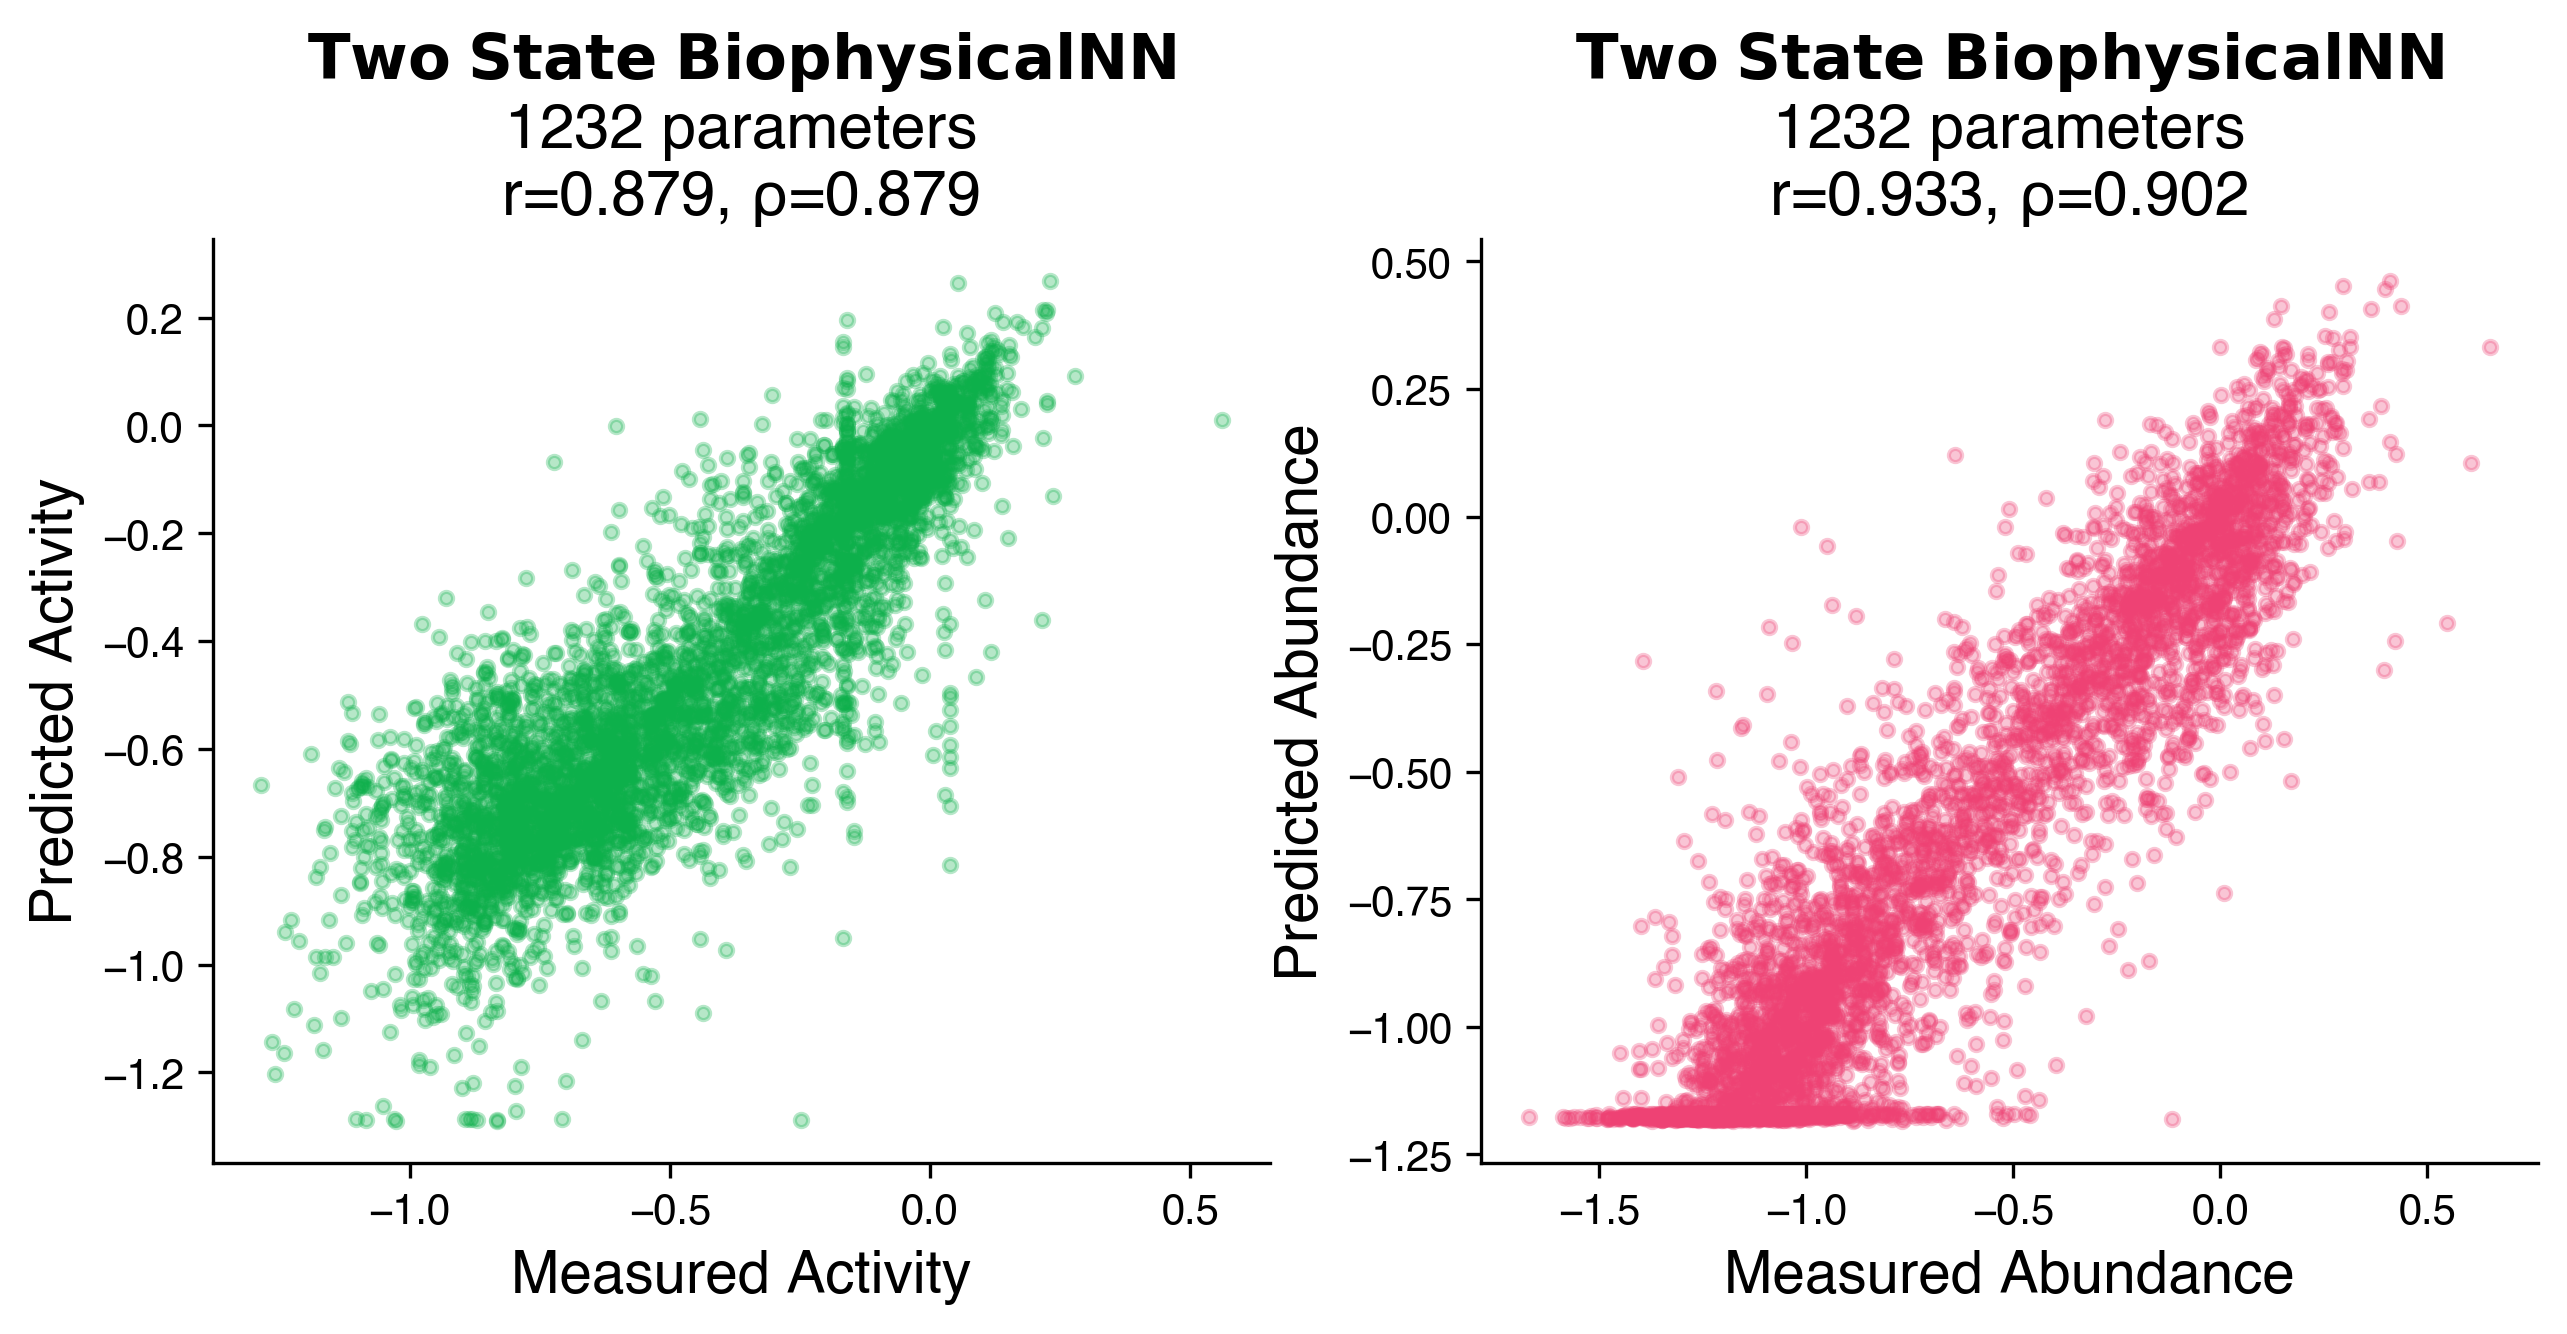

In [75]:
# Code to plot scatter plots for two-state BiophysicalNN, and ADHunter

fig, axs = plt.subplots(1,2,figsize=(10,4))

# Scatter plot for two-state BiophysicalNN - GFP
# tiles = [i for ls in test_seqs["40_tiles"] for i in ls]
# tiles = tiles + (list(other_tiles["aa_seq"]))
# actual = [i for ls in test_seqs["40_tiles_exp_activities"] for i in ls]
# actual = actual + (list(other_tiles["activity"]))
# pred = [i for ls in test_seqs["biophysics_gfp_pred_2"] for i in ls]
# pred = pred + (list(other_tiles["biophysics_gfp_pred_2"]))
plotting_data = train_seqs[['activity', 'biophysics_gfp_pred_2', 'aa_seq']]
plotting_data = plotting_data.dropna()
plotting_data.columns = ["actual", "pred", "aa_seq"]
plotting_data = plotting_data.drop_duplicates("aa_seq") 

axs[0].scatter(plotting_data['actual'], plotting_data['pred'], color='#0DB04B', s=10, alpha=0.3)
spearman = spearmanr(plotting_data["actual"], plotting_data["pred"]).correlation
pearson = pearsonr(plotting_data["actual"].astype('float'), plotting_data["pred"].astype('float')).correlation#np.corrcoef(list(plotting_data["actual"].values), list(plotting_data["pred"].values))[0, 1] ** 2
axs[0].set_xlabel('Measured Activity', fontsize=14)
axs[0].set_ylabel('Predicted Activity', fontsize=14)
axs[0].set_title(r"$\bf{Two}$ $\bf{State}$ $\bf{BiophysicalNN}$" + f'\n1232 parameters\nr={pearson:.3}, \u03C1={spearman:.3}', fontsize=15)

# Scatter plot for two-state BiophysicalNN - mCherry
# tiles = [i for ls in test_seqs["40_tiles"] for i in ls]
# tiles = tiles + (list(other_tiles["aa_seq"]))
# actual = [i for ls in test_seqs["40_tiles_exp_abundance"] for i in ls]
# actual = actual + (list(other_tiles["abundance"]))
# pred = [i for ls in test_seqs["biophysics_mcherry_pred_2"] for i in ls]
# pred = pred + (list(other_tiles["biophysics_mcherry_pred_2"]))
plotting_data = train_seqs[['abundance', 'biophysics_mcherry_pred_2', 'aa_seq']]
plotting_data = plotting_data.dropna()
plotting_data.columns = ["actual", "pred", "aa_seq"]
plotting_data = plotting_data.drop_duplicates("aa_seq") 

axs[1].scatter(plotting_data['actual'], plotting_data['pred'], color='#EE4274', s=10, alpha=0.3)
spearman = spearmanr(plotting_data["actual"], plotting_data["pred"]).correlation
pearson = pearsonr(plotting_data["actual"].astype('float'), plotting_data["pred"].astype('float')).correlation#np.corrcoef(list(plotting_data["actual"].values), list(plotting_data["pred"].values))[0, 1] ** 2
axs[1].set_xlabel('Measured Abundance', fontsize=14)
axs[1].set_ylabel('Predicted Abundance', fontsize=14)
axs[1].set_title(r"$\bf{Two}$ $\bf{State}$ $\bf{BiophysicalNN}$" + f'\n1232 parameters\nr={pearson:.3}, \u03C1={spearman:.3}', fontsize=15)

sns.despine()
# plt.savefig("figures/PADI_two_state_scatter_plots.pdf", format='pdf', bbox_inches='tight')

In [9]:
# # Code to plot scatter plots for three-state BiophysicalNN, and ADHunter

# fig, axs = plt.subplots(1,2,figsize=(10,4))

# # Scatter plot for three-state BiophysicalNN - GFP
# tiles = [i for ls in test_seqs["40_tiles"] for i in ls]
# tiles = tiles + (list(other_tiles["aa_seq"]))
# actual = [i for ls in test_seqs["40_tiles_exp_abundance"] for i in ls]
# actual = actual + (list(other_tiles["abundance"]))
# pred = [i for ls in test_seqs["biophysics_mcherry_pred_3"] for i in ls]
# pred = pred + (list(other_tiles["biophysics_mcherry_pred_3"]))
# plotting_data = pd.DataFrame((actual, pred, tiles)).T
# plotting_data = plotting_data.dropna()
# plotting_data.columns = ["actual", "pred", "aa_seq"]
# plotting_data = plotting_data.drop_duplicates("aa_seq") 

# # Scatter plot for three-state BiophysicalNN - mCherry
# axs[1].scatter(actual, pred, color='#EE4274', s=10, alpha=0.3)
# spearman = spearmanr(plotting_data["actual"], plotting_data["pred"]).correlation
# pearson = pearsonr(plotting_data["actual"].astype('float'), plotting_data["pred"].astype('float')).correlation#np.corrcoef(list(plotting_data["actual"].values), list(plotting_data["pred"].values))[0, 1] ** 2
# axs[1].set_xlabel('Measured Activity', fontsize=14)
# axs[1].set_ylabel('Predicted Activity', fontsize=14)
# axs[1].set_title(r"$\bf{Three}$ $\bf{State}$ $\bf{BiophysicalNN}$" + f'\n1277 parameters\nr={pearson:.3}, \u03C1={spearman:.3}', fontsize=15)

# tiles = [i for ls in test_seqs["40_tiles"] for i in ls]
# tiles = tiles + (list(other_tiles["aa_seq"]))
# actual = [i for ls in test_seqs["40_tiles_exp_activities"] for i in ls]
# actual = actual + (list(other_tiles["activity"]))
# pred = [i for ls in test_seqs["biophysics_gfp_pred_3"] for i in ls]
# pred = pred + (list(other_tiles["biophysics_gfp_pred_3"]))
# plotting_data = pd.DataFrame((actual, pred, tiles)).T
# plotting_data = plotting_data.dropna()
# plotting_data.columns = ["actual", "pred", "aa_seq"]
# plotting_data = plotting_data.drop_duplicates("aa_seq") 

# axs[0].scatter(actual, pred, color='#0DB04B', s=10, alpha=0.3)
# spearman = spearmanr(plotting_data["actual"], plotting_data["pred"]).correlation
# pearson = pearsonr(plotting_data["actual"].astype('float'), plotting_data["pred"].astype('float')).correlation #np.corrcoef(list(plotting_data["actual"].values), list(plotting_data["pred"].values))[0, 1] ** 2
# axs[0].set_xlabel('Measured Abundance', fontsize=14)
# axs[0].set_ylabel('Predicted Abundance', fontsize=14)
# axs[0].set_title(r"$\bf{Three}$ $\bf{State}$ $\bf{BiophysicalNN}$" + f'\n1277 parameters\nr={pearson:.3}, \u03C1={spearman:.3}', fontsize=15)

# sns.despine()
# # plt.savefig(f"figures/PADI_three_state_scatter_plots.pdf", format='pdf', bbox_inches='tight')

# Inspecting the parameters of the two-state BiophysicalNN

In [10]:
# Order of AAs for plotting
amino_acids = ["R","K","H","D","E","M","I","L","V","A","F","Y","W","Q","N","S","T","G","P","C"]

def get_conv_weights(model, layer): 
    """
    Extracts the convolutional layer weights and
    returns them as a pandas dataframe
    """
    model_state_dict = model.state_dict()
    width = model_state_dict[layer].shape[0] * model_state_dict[layer].shape[2]
    conv_weight = model_state_dict[layer].detach().numpy().reshape(width,20)
    conv_weights = pd.DataFrame(conv_weight,columns = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"])
    conv_weights = conv_weights[amino_acids]
    return conv_weights

def get_linear_weights(model, layer, kernel_size):
    """
    Extracts the linear layer weights and
    returns them as a numpy array. Also returns the 
    corresponding x-axis values
    """
    linear_weights = (40 - kernel_size + 1)
    model_state_dict = model.state_dict()
    linear_weight = model_state_dict[layer].detach().numpy().reshape(linear_weights)
    x_vals = np.array(range(0,linear_weights))
    return linear_weight, x_vals


In [11]:
# This is setting up our colors for the plots

# Colors for convolutional filter
colors = [(1, 0, 0), (1, 1, 1), (0, 0, 1)]  # Red, White, Blue
n_bins = 100  # Number of color bins
cmap_name = "custom_colormap"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
custom_cmap.set_bad(color='white', alpha=1.0)  # Handle NaN values, if any

# Colors for AA labels
colors = {'A': 'purple', 'C': 'darkorange', 'E': 'blue', 'D': 'blue', 'G': 'darkorange', 
                  'F': 'indigo', 'I': 'purple', 'H': 'green', 'K': 'green', 'M': 'purple', 
                  'L': 'purple', 'N': 'darkslategray', 'Q': 'darkslategray', 'P': 'darkorange', 'S': 'darkslategray', 
                  'R': 'green', 'T': 'darkslategray', 'W': 'indigo', 'V': 'purple', 'Y': 'indigo'}

In [12]:
def make_row_plot_abund(fig, kernel_size, model, row, lim, height_ratios, num_rows, abund_kernel_size):
    """
    Core functionality for creating the convolutional filter plots. 
    Plots the convolution filter as a heatmap and the linear weights as a bar plot.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object created with plt.figure
    
    kernel_size : int
        The size of the convolutional filter

    model : ADModel_abund
        Loaded model (from which parameters will be extracted)
    
    row : int
        Which row in the overall figure should we fill in

    lim : float
        The max value for the heatmap

    height_ratios : list
        Ratio of heights between rows, length should correspond to number of rows in
        gridspec object

    num_rows : list
        The number of rows in the gridspec object

    Returns
    -------
    ax1 : maplotlib.Axes object
        Contains the heatmap
    ax2 : maplotlib.Axes object
        Contains the barplot
    im1 : maplotlib.Axes.imshow object
        The heatmap
    """

    # Load the convolutional and linear weights for both NN blocks
    model_conv1 = get_conv_weights(model, "conv1.weight").T
    model_linear1, model_xvals1 = get_linear_weights(model, "linear1.weight", kernel_size)

    model_conv2 = get_conv_weights(model, "conv2.weight").T
    model_linear2, model_xvals2 = get_linear_weights(model, "linear2.weight", abund_kernel_size)

    # Calculate how much of the figure the convolutional filters vs. linear weights will take up
    ratio1 = kernel_size 
    ratio2 = 56 - kernel_size + 1
    ratio1_abund = abund_kernel_size
    ratio2_abund = 56 - abund_kernel_size + 1

    # GridSpec allows us to plot rows/columns with different dimensions
    # Here, we initalize the gridspec object with the total number of rows in our figure
    # But we only fill in the specific row that we are interested in
    # (When combined with many other gridspec objects, they will all line up and look good)
    gs1 = gridspec.GridSpec(2 + num_rows, 5, width_ratios=[ratio1, ratio2, 0.5, ratio1_abund, ratio2_abund], height_ratios=height_ratios, figure=fig)
    
    # axs are matplotlib axes
    ax1 = plt.subplot(gs1[row, 0])
    ax2 = plt.subplot(gs1[row, 1])
    ax3 = plt.subplot(gs1[row, 3])
    ax4 = plt.subplot(gs1[row, 4])


    ## Code for first set of parameters --> K1 predictor
    # This is the code for plotting the convolutional filter as a heatmap
    # Min and max values of heatmap are passed by used
    im1 = ax1.imshow(model_conv1.to_numpy(), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    ax1.set_yticks(range(len(model_conv1.index)), model_conv1.index)  # Label x-axis with column names
    ax1.set_xticks(np.arange(kernel_size, step=2))

    # This is to color the amino acid labels
    for ytic in ax1.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax1.tick_params(axis='both', which='major', labelsize=6) 

    # This is the code for plotting the linear weights as a bar graph
    ax2.bar(model_xvals1, model_linear1, color="grey")
    ax2.spines["top"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["bottom"].set_position('zero')
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_xticklabels([])
    ax2.set_yticklabels([])

    ## Code for second set of parameters --> abundance predictor
    # This is the code for plotting the convolutional filter as a heatmap
    # Min and max values of heatmap are passed by used
    im2 = ax3.imshow(model_conv2.to_numpy(), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    ax3.set_yticks(range(len(model_conv2.index)), model_conv2.index)  # Label x-axis with column names
    ax3.set_xticks(np.arange(abund_kernel_size, step=2))
    
    # This is to color the amino acid labels
    for ytic in ax3.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax3.tick_params(axis='both', which='major', labelsize=6) 

    # This is the code for plotting the linear weights as a bar graph
    ax4.bar(model_xvals2, model_linear2, color="grey")
    ax4.spines["top"].set_visible(False)
    ax4.spines["left"].set_visible(False)
    ax4.spines["right"].set_visible(False)
    ax4.spines["bottom"].set_position('zero')
    ax4.set_xticks([])
    ax4.set_yticks([])
    ax4.set_xticklabels([])
    ax4.set_yticklabels([])


    return ax1, ax2, ax3, ax4, im1, im2


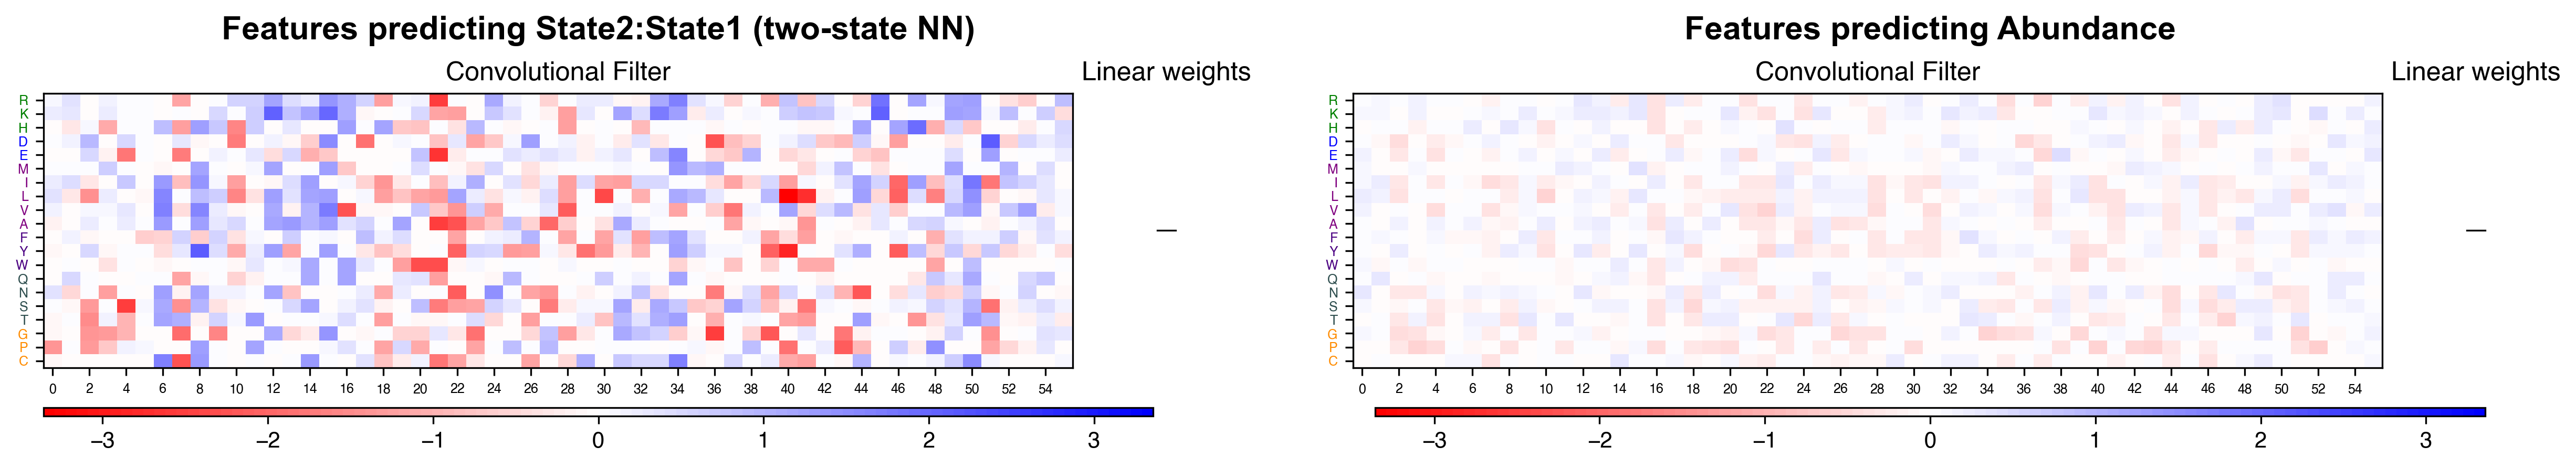

In [76]:
# Get the range for the heatmaps
models = [two_state_biophysical_model]
conv_weights = []

for model in models: 
    conv_weights += list(get_conv_weights(model, "conv1.weight").T.values.flatten())
    conv_weights += list(get_conv_weights(model, "conv2.weight").T.values.flatten())

# Max value for heatmaps
lim = max([abs(w) for w in conv_weights])

num_rows = 1

# Create a figure
fig = plt.figure(figsize=(20, 3*num_rows))
title_font = {'fontsize': 15, 'fontweight': 'bold', 'fontname': 'Arial'}

# We add in "padding" rows between the rows we care about
height_ratios = [.3] + [3.3]*num_rows + [.1]*2

# Create a gridspec object
gs1 = gridspec.GridSpec(3 + num_rows, 2, width_ratios=[1,1], height_ratios=height_ratios, figure=fig)

# Making the first row a title row
ax1 = plt.subplot(gs1[0,0])
ax1.set_title("Features predicting State2:State1 (two-state NN)", fontdict=title_font)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.patch.set_visible(False)
ax1.axis('off')

ax2 = plt.subplot(gs1[0,1])
ax2.set_title("Features predicting Abundance", fontdict=title_font)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.patch.set_visible(False)
ax2.axis('off')

# Adding the best NN parameters to the first row
ax1, ax2, ax3, ax4, im1, im2 = make_row_plot_abund(fig, kernel_size_two, two_state_biophysical_model, 1, lim, height_ratios, num_rows+1, abund_k_two)

ax1.set_title("Convolutional Filter", fontsize=12)
ax2.set_title("Linear weights", fontsize=12)
ax3.set_title("Convolutional Filter", fontsize=12)
ax4.set_title("Linear weights", fontsize=12)

# Create another gridspec object to span the whole figure (1 column) to display the colorbar
gs_cb = gridspec.GridSpec(3 + num_rows, 2, width_ratios=[1,1], height_ratios=height_ratios, figure=fig)
cax1 = plt.subplot(gs_cb[2 + num_rows, 0])
cax2 = plt.subplot(gs_cb[2 + num_rows, 1])

# Add the colorbar
fig.colorbar(im1,cax=cax1, orientation='horizontal')
fig.colorbar(im2, cax=cax2, orientation='horizontal')

# plt.savefig('figures/Faure_two_state_parameters.pdf', dpi=1000, bbox_inches='tight')

In [14]:
get_linear_weights(two_state_biophysical_model, layer='linear1.weight', kernel_size=56)

(array([-3.054], dtype=float32), array([], dtype=float64))

<BarContainer object of 20 artists>

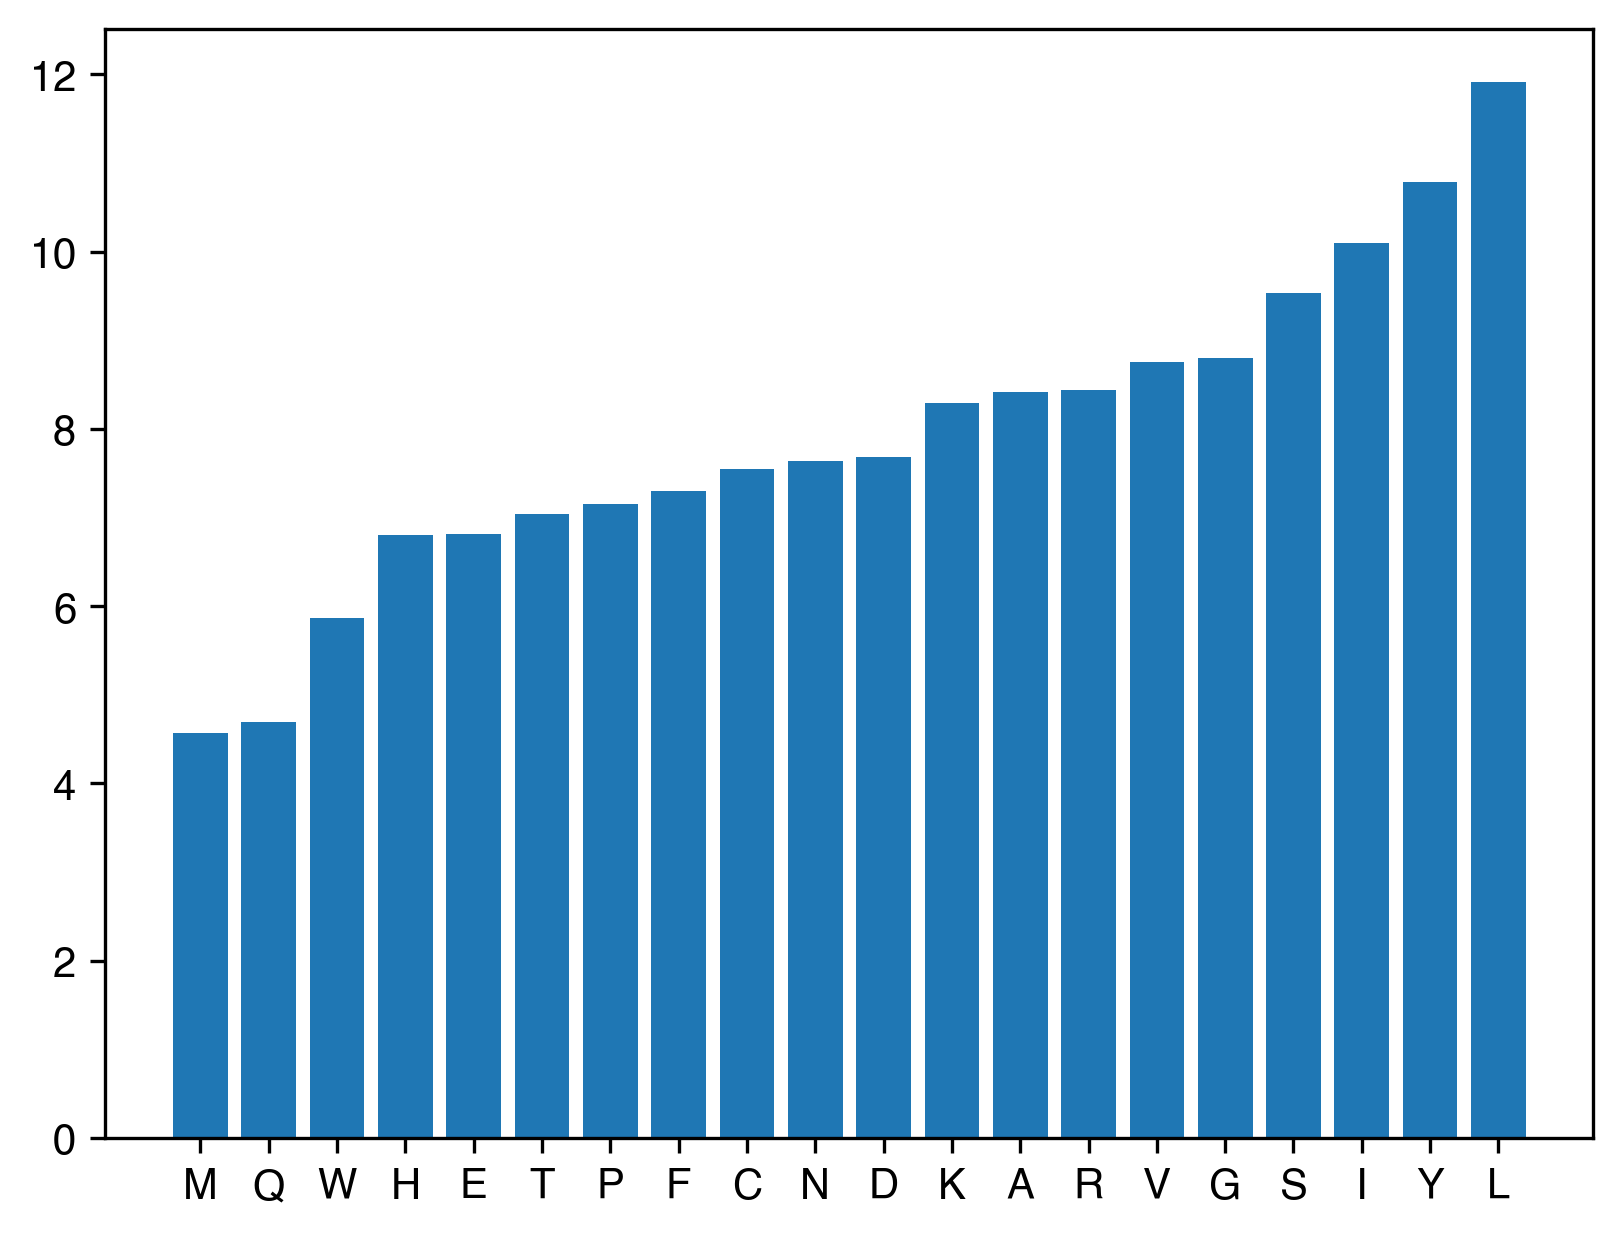

In [56]:
conv_weights = get_conv_weights(two_state_biophysical_model, layer='conv1.weight')

# Control could be to shuffle row wise
plt.bar(np.abs(conv_weights).sum().sort_values().index, height=np.abs(conv_weights).sum().sort_values())

# Compare with their results

In [77]:
# Our data
all_seqs = pd.concat([train_seqs, val_seqs, test_seqs])

R = 0.001987
T = 303

all_seqs['delta_G_b'] = [-R * T * np.log(K) for K in all_seqs["K1"]]

/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_8707/3231238284.py:7: RuntimeWarning: invalid value encountered in log
  all_seqs['delta_G_b'] = [-R * T * np.log(K) for K in all_seqs["K1"]]


In [58]:
WT_seq = "TYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGMFPRNYVTPVN"

In [78]:
# Their data
inferred_delta_G = pd.read_csv('/Users/claireleblanc/Downloads/41586_2022_4586_MOESM10_ESM.csv')
inferred_delta_G = inferred_delta_G[inferred_delta_G['protein'] == "GRB2-SH3"]

inferred_delta_G["aa_seq"] = [WT_seq[:int(inferred_delta_G.loc[i, 'Pos']) - 1] + inferred_delta_G.loc[i, 'Mut'] + WT_seq[int(inferred_delta_G.loc[i, 'Pos']):] if not np.isnan(inferred_delta_G.loc[i, 'Pos']) else WT_seq for i in inferred_delta_G.index]

# Missing all double mutants and sequences with no binding data
merged_data = inferred_delta_G.merge(all_seqs, on='aa_seq')
# merged_data = merged_data[merged_data['K1'] > 0]

# merged_data = merged_data[merged_data['b_ddg_pred_conf']]

In [79]:
merged_data['Pos_class'].value_counts()

Pos_class
surface              351
core                 144
binding_interface    141
Name: count, dtype: int64

PearsonRResult(statistic=0.6384320793515337, pvalue=3.1666735005400394e-74)

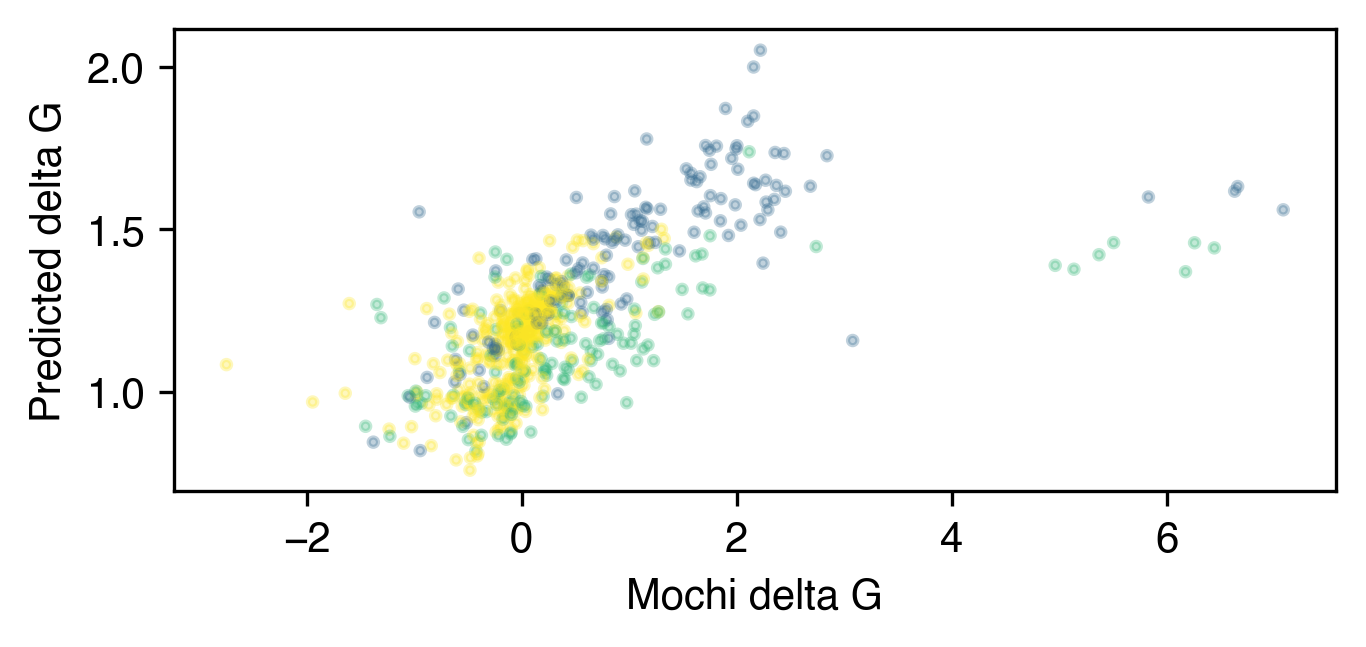

In [80]:
# For plotting calculated delta G
plt.figure(figsize=(5, 2))
merged_data_subset = merged_data #[merged_data['Pos_class'] == 'surface']
plt.scatter(merged_data_subset['b_ddg_pred'], merged_data_subset['delta_G_b'], s=5, alpha=0.3, c=merged_data_subset['Pos_class'].astype('category').cat.codes, cmap='viridis')
plt.xlabel("Mochi delta G")
plt.ylabel("Predicted delta G")
# plt.yscale('log')
pearsonr(merged_data_subset['b_ddg_pred'], np.log(merged_data_subset['K1']))
pearsonr(merged_data_subset['b_ddg_pred'], merged_data_subset['delta_G_b'])

PearsonRResult(statistic=-0.7401161218682152, pvalue=1.2760413394672653e-109)

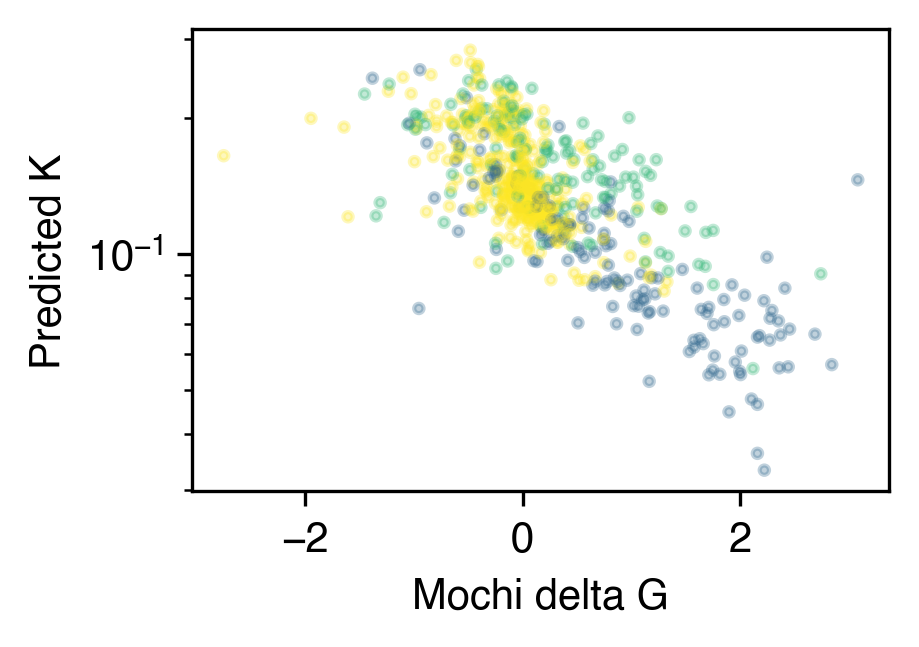

In [84]:
# For plotting K vs. G
plt.figure(figsize=(3, 2))
merged_data_subset = merged_data[(merged_data['b_ddg_pred'] < 4)] #[merged_data['Pos_class'] == 'surface']
plt.scatter(merged_data_subset['b_ddg_pred'], merged_data_subset['K1'], s=5, alpha=0.3, c=merged_data_subset['Pos_class'].astype('category').cat.codes, cmap='viridis')
plt.xlabel("Mochi delta G")
plt.ylabel("Predicted K")
plt.yscale('log')
pearsonr(merged_data_subset['b_ddg_pred'], np.log(merged_data_subset['K1']))

# plt.xlim(-2, 3)

# plt.colorbar()
# Purple in binding interface
# Blue is core
# Yellow is sufrace
# plt.savefig('figures/PADI_two_state_parameters.pdf', dpi=1000, bbox_inches='tight')

In [85]:
# Correlation w/ main model
params = pd.read_table('/Users/claireleblanc/Downloads/Data/mochi/GRB2-SH3/mochi__fit_tmodel_3state_sparse_dimsum128/model_weights_0.txt')
params['orig_AA'] = params['id'].str[0]
params['new_AA'] = params['id'].str[-1]
params['location'] = [int(re.findall("\d+", s)[0]) if s != "WT" else -1 for s in params['id']]
binding_data = params.pivot(columns="location", index='new_AA', values='binding_coefficient').loc[amino_acids]

# Get correlation w/ bootstrap
conv_weights = get_conv_weights(two_state_biophysical_model, layer='conv1.weight')
our_weights = conv_weights.T.values.flatten()
their_weights = binding_data.drop(columns=[-1]).values.flatten()


df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()

print(pearsonr(df['theirs'], df['ours']).correlation)


0.5034188137794611


In [86]:
# Loop through bootstraps and look at correlations - BINDING

for i in range(1, 11):
    # Read in bootstrap params
    params = pd.read_table(f'/Users/claireleblanc/Downloads/Data/mochi/GRB2-SH3/mochi__fit_tmodel_3state_sparse_dimsum128/bootstrap/boot_{i}/model_weights_0.txt')
    params['orig_AA'] = params['id'].str[0]
    params['new_AA'] = params['id'].str[-1]
    params['location'] = [int(re.findall("\d+", s)[0]) if s != "WT" else -1 for s in params['id']]
    binding_data = params.pivot(columns="location", index='new_AA', values='binding_coefficient').loc[amino_acids]

    # Get correlation w/ bootstrap
    conv_weights = get_conv_weights(two_state_biophysical_model, layer='conv1.weight')

    our_weights = conv_weights.T.values.flatten()
    their_weights = binding_data.drop(columns=[-1]).values.flatten()


    df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()

    print(pearsonr(df['theirs'], df['ours']).correlation)


0.4963828282380478
0.5073439945748112
0.49712571415522977
0.5034650882451175
0.47294224496782156
0.47972371333360975
0.5120424871729395
0.45791644844304313
0.4974360717305155
0.5035294553765313


In [88]:
# Loop through bootstraps and look at correlations - FOLDING

for i in range(1, 11):
    # Read in bootstrap params
    params = pd.read_table(f'/Users/claireleblanc/Downloads/Data/mochi/GRB2-SH3/mochi__fit_tmodel_3state_sparse_dimsum128/bootstrap/boot_{i}/model_weights_0.txt')
    params['orig_AA'] = params['id'].str[0]
    params['new_AA'] = params['id'].str[-1]
    params['location'] = [int(re.findall("\d+", s)[0]) if s != "WT" else -1 for s in params['id']]
    binding_data = params.pivot(columns="location", index='new_AA', values='binding_coefficient').loc[amino_acids]
    folding_data = params.pivot(columns="location", index='new_AA', values='folding_coefficient').loc[amino_acids]

    # Get correlation w/ bootstrap
    conv_weights = get_conv_weights(two_state_biophysical_model, layer='conv2.weight')

    our_weights = conv_weights.T.values.flatten()
    their_weights = folding_data.drop(columns=[-1]).values.flatten()


    df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()

    print(pearsonr(df['theirs'], df['ours']).correlation)


-0.6104138129188819
-0.6179454492530398
-0.6141716555696985
-0.6102071496759349
-0.6345020281305978
-0.6234922719720848
-0.605213915057645
-0.5988697190205066
-0.6131750428874999
-0.6123849515675656


In [85]:
# Look at correlation between seeds
size = (1,56,20)
import torch 

def load_model(name, k, ak):
    """
    Loads ADModel_two_state_abund
    """
    model = ADModel_two_state_abund(size, "Hill", k, relu=False, abund_k=ak)
    model.load_state_dict(torch.load(f"{name}.pth"))
    return model

models = []

# Load each NN and save in a list
for index in two_model_results[two_model_results['pearson_act_val'] > 0.7].index:
    K = two_model_results.loc[index, "kernel_size"]
    name = two_model_results.loc[index, "model_name"].removeprefix("../../")
    ak = 56

    models.append(load_model(name, K, ak))


In [102]:
example = "../../model_data/Faure_two_state_abundmodel_b10_e200_L0.001_sMinMax_aHill_c1_k56_ak56_LeakyReLU_0.1PosKLoss_0.5PosWeightLoss_hSplit_hv1_seed830655019_weightInit"

two_model_results[[example in n for n in two_model_results['model_name']]]['pearson_abund_train']

8     0.546965
9    -0.319589
10   -0.319589
Name: pearson_abund_train, dtype: float64

In [111]:
example = load_model(two_model_results[[example in n for n in two_model_results['model_name']]].loc[9, 'model_name'].removeprefix("../../"), K, ak)

TypeError: 'in <string>' requires string as left operand, not ADModel_two_state_abund

(array([1.000, 2.000, 2.000, 4.000, 3.000, 1.000, 0.000, 2.000, 0.000,
        6.000]),
 array([-0.580, -0.431, -0.282, -0.132, 0.017, 0.166, 0.315, 0.464, 0.614,
        0.763, 0.912]),
 <BarContainer object of 10 artists>)

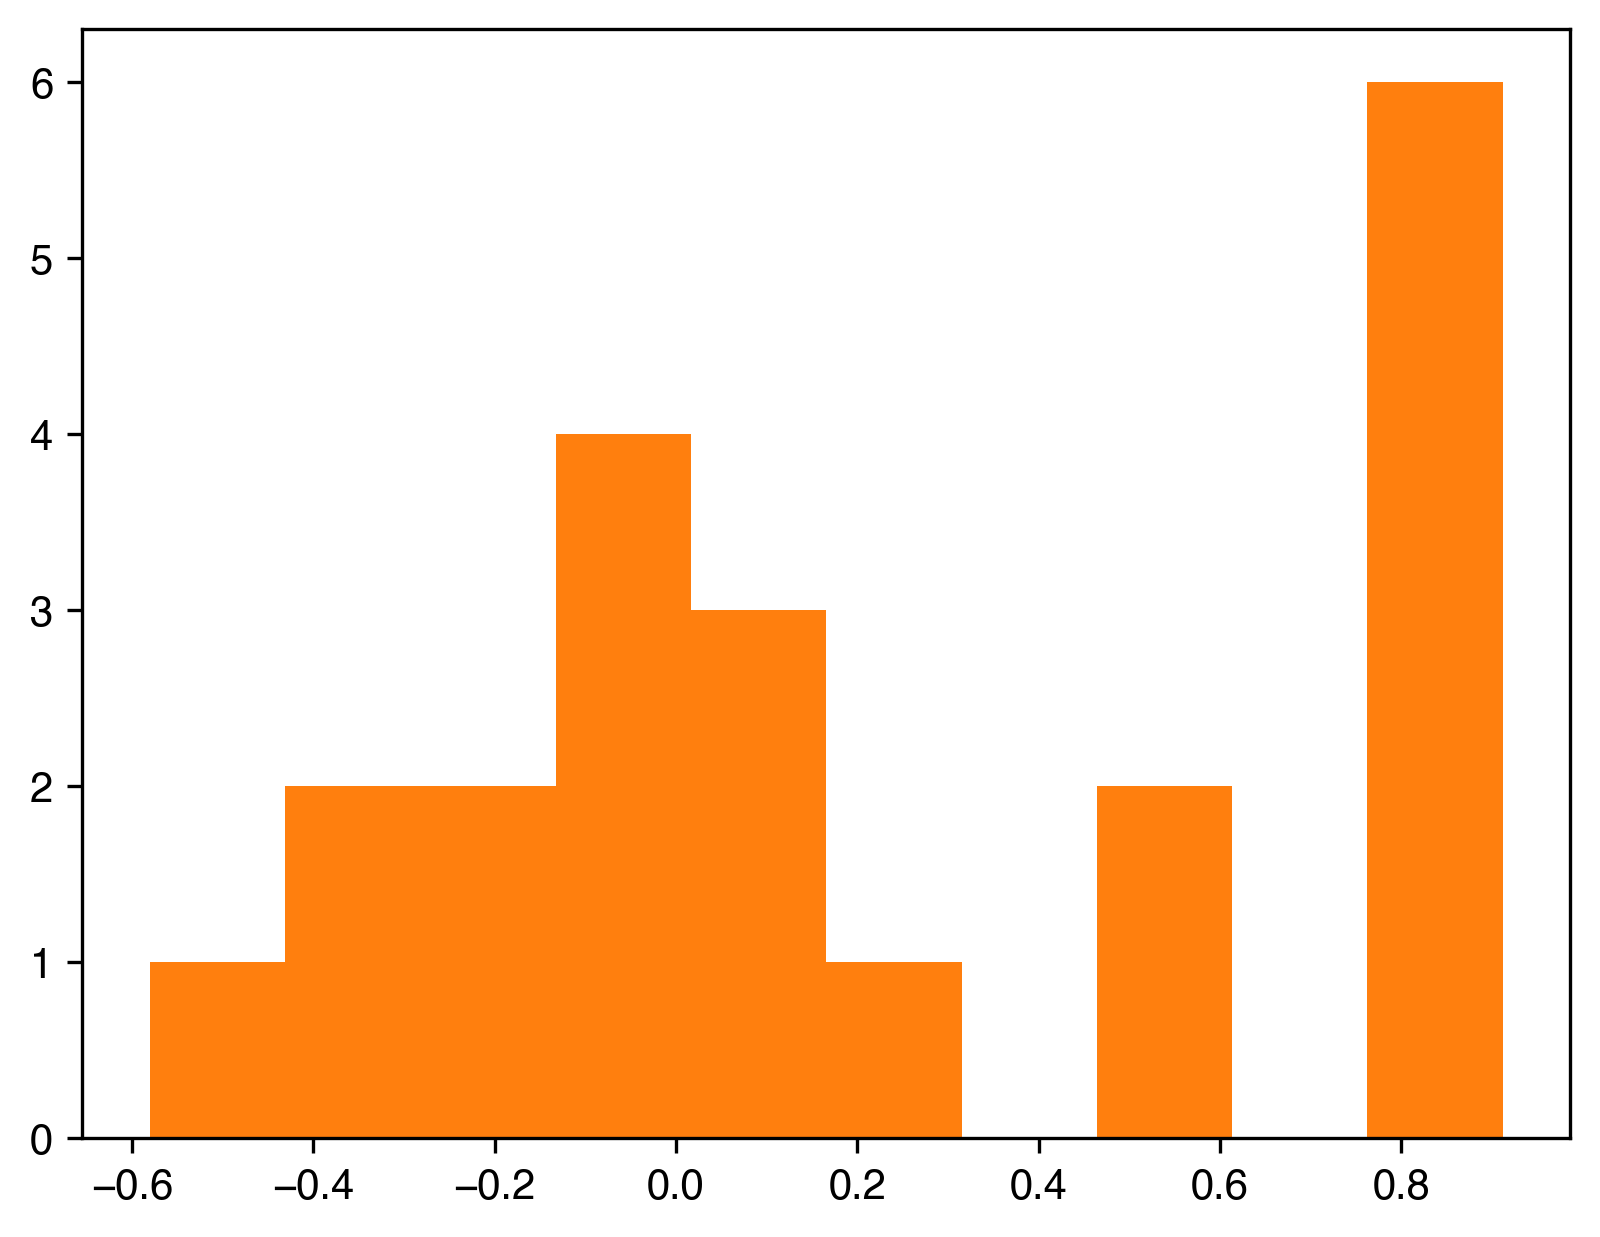

In [99]:
plt.hist(two_model_results[["noEarlyStopping" in n for n in two_model_results['model_name']]]['pearson_act_train'])
plt.hist(two_model_results['spearman_act_train'])

In [88]:
our_weights = conv_weights.T.values.flatten()
their_weights = binding_data.drop(columns=[-1]).values.flatten()

df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()
# df = df[df['ours'] > 0]

print(pearsonr(df['theirs'], df['ours']))
print(spearmanr(df['theirs'], df['ours']))

PearsonRResult(statistic=-0.4230338802030204, pvalue=3.5477363903766683e-34)
SignificanceResult(statistic=-0.5555440021518214, pvalue=1.9417286563743117e-62)


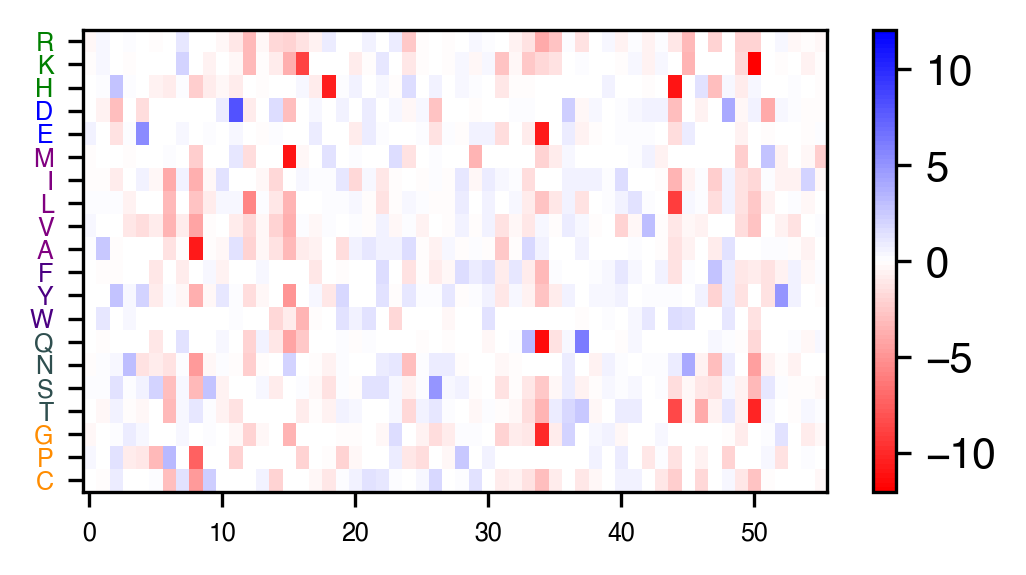

In [300]:
lim = max(np.abs(binding_data.min().min()), np.abs(binding_data.max().max()))
fig, ax1 = plt.subplots(1, 1, figsize=(4, 2))
im1 = ax1.imshow(binding_data.drop(columns=[-1]).to_numpy() * -1, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
ax1.set_yticks(range(len(binding_data.index)), binding_data.index)  # Label x-axis with column names
# ax1.set_xticks(np.arange(kernel_size, step=2))

# This is to color the amino acid labels
for ytic in ax1.get_yticklabels():
    if ytic.get_text() in colors.keys(): 
        ytic.set_color(colors[ytic.get_text()])
ax1.tick_params(axis='both', which='major', labelsize=6) 

plt.colorbar(im1)

In [49]:
na_mask = np.isnan(binding_data.drop(columns=[-1]).to_numpy())

In [54]:
na_mask.shape

(20, 56)

In [57]:
conv_weights.T.to_numpy()[na_mask].shape

(364,)

In [63]:
sum(na_mask)

array([ 8,  6,  6,  6, 10,  9,  8,  5,  8,  6,  8,  5,  9,  5,  8,  8,  8,
        6,  8,  5,  5,  8,  7,  4,  6,  3,  6,  4,  6,  5,  7,  7,  4,  4,
        6,  8,  7,  7,  8, 10,  4,  6,  8,  6,  4,  8,  9,  9,  5,  4,  6,
        6,  7,  7,  6,  5])

In [64]:
np.where(~na_mask, conv_weights.T.to_numpy(), -20)

array([[-0.044, -0.113, -20.000, ..., 0.214, -0.020, -0.188],
       [-0.033, -0.099, -20.000, ..., -20.000, -0.026, 0.117],
       [-20.000, 0.058, 0.043, ..., 0.051, -20.000, -0.215],
       ...,
       [0.055, -20.000, 0.414, ..., -20.000, -0.107, -0.015],
       [0.441, -20.000, 0.343, ..., -20.000, -0.094, -20.000],
       [-20.000, -0.004, 0.063, ..., -20.000, -20.000, 0.053]],
      dtype=float32)

In [ ]:
lim = max(np.abs(conv_weights.min().min()), np.abs(conv_weights.max().max()))

plotting_weights = np.where(~na_mask, conv_weights.T.to_numpy(), np.nan)
# plotting_weights = conv_weights.T.to_numpy()

fig, ax1 = plt.subplots(1, 1, figsize=(4, 2))

custom_cmap.set_bad('lightgrey',1.)
# plt.imshow(plotting_weights, interpolation='nearest', cmap=cmap, aspect='auto',vmin=-lim,vmax=lim)

im1 = ax1.imshow(plotting_weights, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
ax1.set_yticks(range(len(conv_weights.T.index)), conv_weights.T.index)  # Label x-axis with column names
# ax1.set_xticks(np.arange(kernel_size, step=2))

# This is to color the amino acid labels
for ytic in ax1.get_yticklabels():
    if ytic.get_text() in colors.keys(): 
        ytic.set_color(colors[ytic.get_text()])
ax1.tick_params(axis='both', which='major', labelsize=6) 

plt.colorbar(im1)

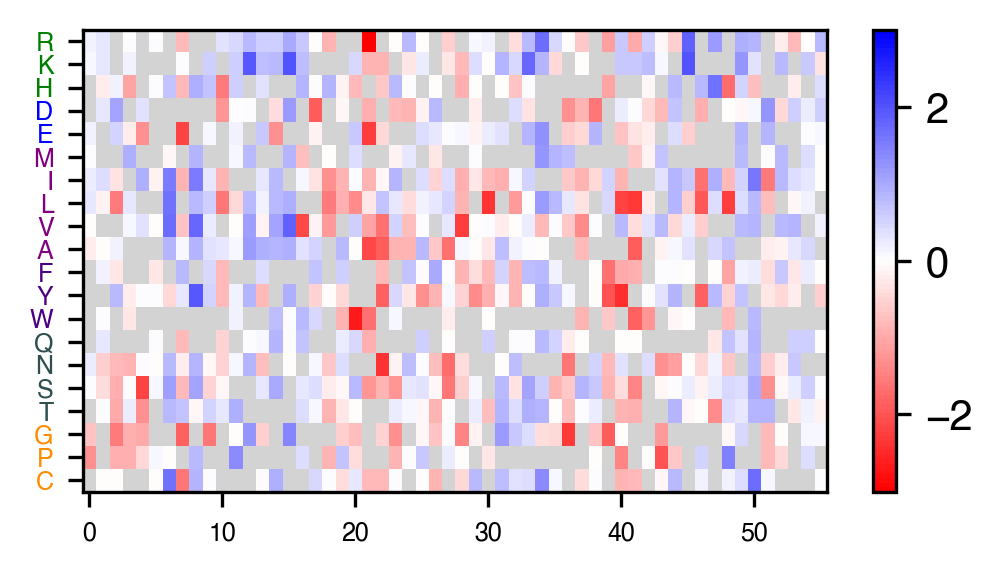

In [301]:
conv_weights = get_conv_weights(two_state_biophysical_model, layer='conv1.weight')
na_mask = np.isnan(binding_data.drop(columns=[-1]).to_numpy())
lim = max(np.abs(conv_weights.min().min()), np.abs(conv_weights.max().max()))

plotting_weights = np.where(~na_mask, conv_weights.T.to_numpy(), np.nan)
# plotting_weights = conv_weights.T.to_numpy()

fig, ax1 = plt.subplots(1, 1, figsize=(4, 2))

custom_cmap.set_bad('lightgrey',1.)
# plt.imshow(plotting_weights, interpolation='nearest', cmap=cmap, aspect='auto',vmin=-lim,vmax=lim)

im1 = ax1.imshow(plotting_weights, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
ax1.set_yticks(range(len(conv_weights.T.index)), conv_weights.T.index)  # Label x-axis with column names
# ax1.set_xticks(np.arange(kernel_size, step=2))

# This is to color the amino acid labels
for ytic in ax1.get_yticklabels():
    if ytic.get_text() in colors.keys(): 
        ytic.set_color(colors[ytic.get_text()])
ax1.tick_params(axis='both', which='major', labelsize=6) 

plt.colorbar(im1)

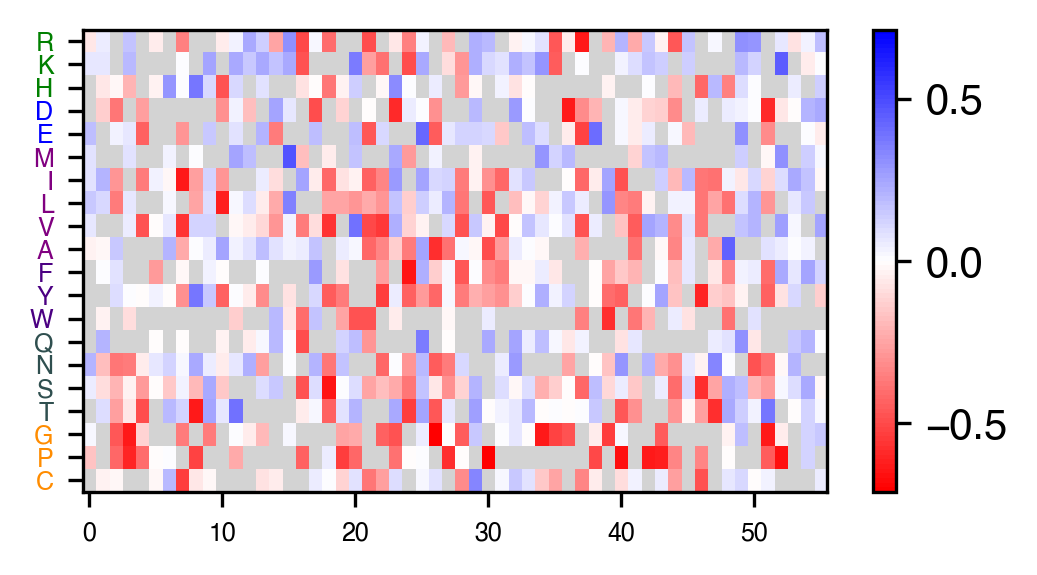

In [124]:
conv_weights = get_conv_weights(two_state_biophysical_model, layer='conv2.weight')
na_mask = np.isnan(binding_data.drop(columns=[-1]).to_numpy())
lim = max(np.abs(conv_weights.min().min()), np.abs(conv_weights.max().max()))

plotting_weights = np.where(~na_mask, conv_weights.T.to_numpy(), np.nan)
# plotting_weights = conv_weights.T.to_numpy()

fig, ax1 = plt.subplots(1, 1, figsize=(4, 2))

custom_cmap.set_bad('lightgrey',1.)
# plt.imshow(plotting_weights, interpolation='nearest', cmap=cmap, aspect='auto',vmin=-lim,vmax=lim)

im1 = ax1.imshow(plotting_weights, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
ax1.set_yticks(range(len(conv_weights.T.index)), conv_weights.T.index)  # Label x-axis with column names
# ax1.set_xticks(np.arange(kernel_size, step=2))

# This is to color the amino acid labels
for ytic in ax1.get_yticklabels():
    if ytic.get_text() in colors.keys(): 
        ytic.set_color(colors[ytic.get_text()])
ax1.tick_params(axis='both', which='major', labelsize=6) 

plt.colorbar(im1)

In [242]:
np.nanargmax(plotting_weights[:, 0])

18

In [249]:
binding_data

location,-1,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
new_AA,,,,,,,,,,,,,,,,,,,,,
R,NaN,0.411384,0.071913,NaN,-0.001877,NaN,0.295973,NaN,-1.433393,NaN,...,NaN,1.972470,NaN,1.695888,1.938787,NaN,-0.683829,0.269784,-0.876691,-0.095500
K,NaN,0.027083,0.132176,NaN,0.210727,NaN,NaN,NaN,-1.177519,NaN,...,NaN,NaN,NaN,1.917059,-1.583332,NaN,0.059968,NaN,1.233893,0.092536
H,NaN,NaN,-0.111500,-3.181988,-0.199598,NaN,0.647357,1.071207,-0.263846,1.746801,...,0.304357,2.926097,-0.473035,0.841607,-0.394212,NaN,NaN,-0.123117,NaN,0.221541
D,NaN,NaN,0.798801,2.907636,NaN,1.263196,NaN,NaN,NaN,NaN,...,0.024131,NaN,-4.310266,0.240225,-0.166571,3.514520,-4.561535,-0.176107,0.006808,0.127942
E,NaN,-0.038914,NaN,0.767888,-0.159426,-2.411614,NaN,NaN,-0.305186,NaN,...,NaN,NaN,NaN,0.386959,NaN,2.221125,NaN,NaN,0.160491,-0.150943
M,NaN,-0.149663,NaN,NaN,0.549505,NaN,NaN,1.498892,NaN,9.682658,...,NaN,NaN,NaN,1.768463,NaN,-2.950778,0.087027,NaN,0.336783,0.136374
I,NaN,0.125236,-0.130781,0.782587,NaN,-0.636673,0.259847,3.934629,-1.312897,3.768303,...,0.141443,1.487000,-0.664872,1.344108,1.931087,-0.157711,0.663237,0.480173,-0.064496,0.263591
L,NaN,0.115411,-0.409850,-0.148650,0.533747,NaN,NaN,3.245368,NaN,2.664117,...,-0.172116,1.623718,-0.750043,-0.400897,2.614350,0.466058,NaN,-0.026879,0.386122,NaN
V,NaN,-0.527461,NaN,NaN,0.512944,1.478605,0.903001,3.325831,0.881970,4.052858,...,0.662715,NaN,NaN,1.288632,2.144913,NaN,0.729151,0.946371,NaN,-0.289166


In [256]:
for i in np.nanargmin(binding_data.values, axis=0):
    print(conv_weights.columns[i])

T
V
A
H
N
Y
S
P
C
T
S
I
D
D
Q
D
N
S
E
M
Y
H
C
Y
M
H
E
S
Y
F
E
I
I
K
Q
A
T
D
Q
I
L
I
L
V
K
W
E
Y
F
D
L
K
M
D
F
R
Q


In [245]:
for i in np.nanargmax(plotting_weights, axis=0):
    print(conv_weights.columns[i])

P
L
G
G
S
H
Y
G
T
G
D
L
D
Y
E
W
V
D
I
Y
W
R
A
G
V
Y
T
N
V
Y
L
I
H
H
G
K
G
V
D
Y
Y
L
W
P
P
E
L
T
L
D
H
I
D
R
R
Y


In [219]:
binding_data

location,-1,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
new_AA,,,,,,,,,,,,,,,,,,,,,
R,NaN,0.411384,0.071913,NaN,-0.001877,NaN,0.295973,NaN,-1.433393,NaN,...,NaN,1.972470,NaN,1.695888,1.938787,NaN,-0.683829,0.269784,-0.876691,-0.095500
K,NaN,0.027083,0.132176,NaN,0.210727,NaN,NaN,NaN,-1.177519,NaN,...,NaN,NaN,NaN,1.917059,-1.583332,NaN,0.059968,NaN,1.233893,0.092536
H,NaN,NaN,-0.111500,-3.181988,-0.199598,NaN,0.647357,1.071207,-0.263846,1.746801,...,0.304357,2.926097,-0.473035,0.841607,-0.394212,NaN,NaN,-0.123117,NaN,0.221541
D,NaN,NaN,0.798801,2.907636,NaN,1.263196,NaN,NaN,NaN,NaN,...,0.024131,NaN,-4.310266,0.240225,-0.166571,3.514520,-4.561535,-0.176107,0.006808,0.127942
E,NaN,-0.038914,NaN,0.767888,-0.159426,-2.411614,NaN,NaN,-0.305186,NaN,...,NaN,NaN,NaN,0.386959,NaN,2.221125,NaN,NaN,0.160491,-0.150943
M,NaN,-0.149663,NaN,NaN,0.549505,NaN,NaN,1.498892,NaN,9.682658,...,NaN,NaN,NaN,1.768463,NaN,-2.950778,0.087027,NaN,0.336783,0.136374
I,NaN,0.125236,-0.130781,0.782587,NaN,-0.636673,0.259847,3.934629,-1.312897,3.768303,...,0.141443,1.487000,-0.664872,1.344108,1.931087,-0.157711,0.663237,0.480173,-0.064496,0.263591
L,NaN,0.115411,-0.409850,-0.148650,0.533747,NaN,NaN,3.245368,NaN,2.664117,...,-0.172116,1.623718,-0.750043,-0.400897,2.614350,0.466058,NaN,-0.026879,0.386122,NaN
V,NaN,-0.527461,NaN,NaN,0.512944,1.478605,0.903001,3.325831,0.881970,4.052858,...,0.662715,NaN,NaN,1.288632,2.144913,NaN,0.729151,0.946371,NaN,-0.289166


In [222]:
plotting_weights.shape

(20, 56)

In [223]:
binding_data.drop(columns=[-1]).to_numpy().shape

(20, 56)

In [251]:
pearsonr(plotting_weights[i, :], binding_data.drop(columns=[-1]).to_numpy()[i, :]).correlation

nan

AttributeError: 'numpy.ndarray' object has no attribute 'dropnan'

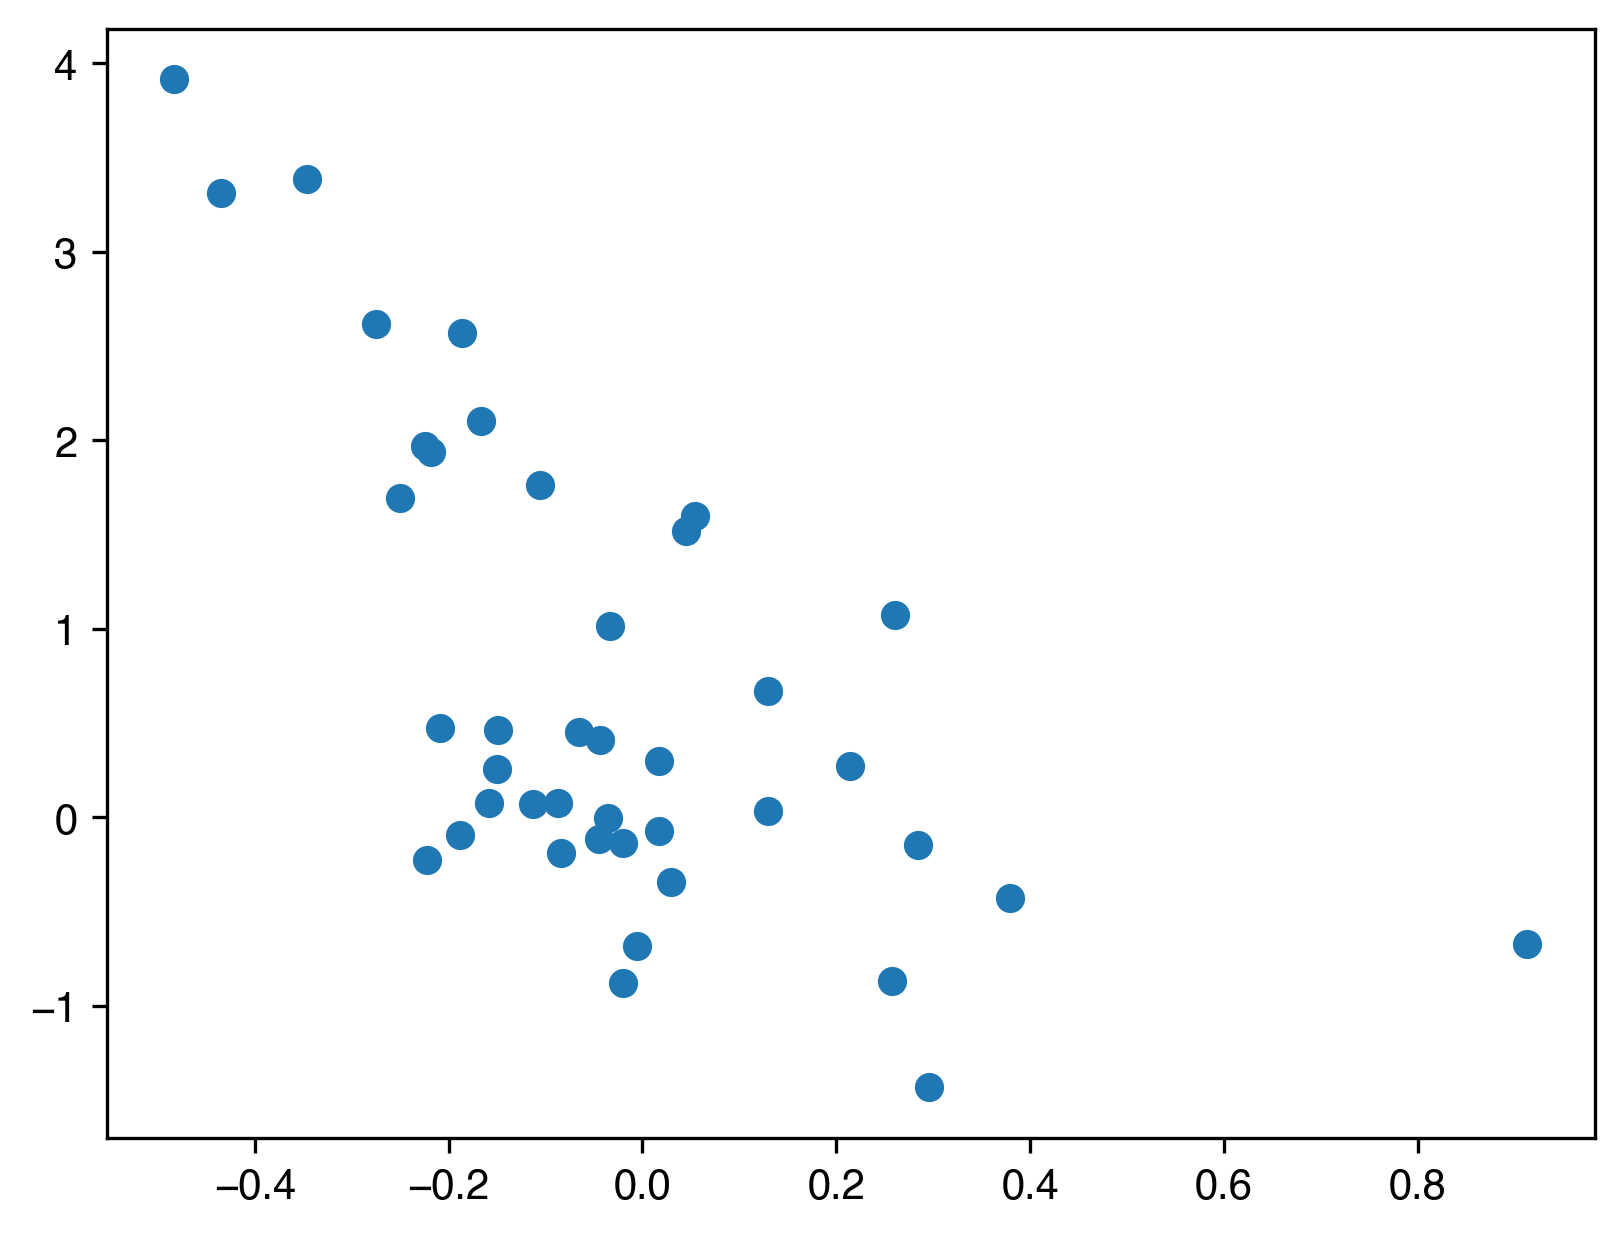

In [253]:
for i in range(20):
    plt.scatter(plotting_weights[i, :], binding_data.drop(columns=[-1]).to_numpy()[i, :])
    plt.title(conv_weights.T.index[i], pearsonr(plotting_weights.dropnan()[i, :], binding_data.dropnan().drop(columns=[-1]).to_numpy()[i, :]).correlation)
    plt.show()

In [123]:
merged_data[merged_data['Pos_class'] == 'binding_interface']["Pos"].unique()

array([7.000, 9.000, 12.000, 13.000, 16.000, 32.000, 34.000, 35.000,
       37.000, 46.000, 48.000, 50.000, 51.000])

PearsonRResult(statistic=-0.12670068306896687, pvalue=0.3612651207852544)


Text(0.5, 0, 'Ours')

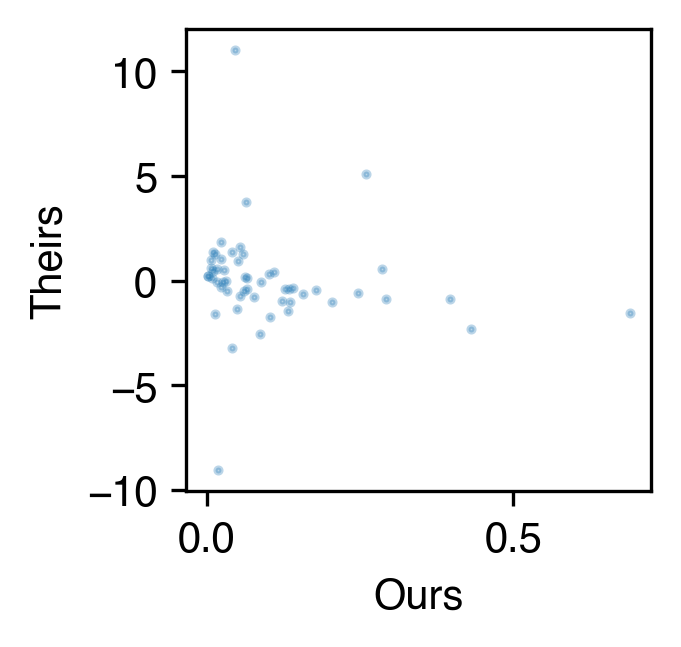

In [36]:
binding_positions = [7.000, 9.000, 12.000, 13.000, 16.000, 32.000, 34.000, 35.000,
       37.000, 46.000, 48.000, 50.000, 51.000]

their_weights = binding_data.drop(columns=[-1])[binding_positions].values.flatten()

binding_positions = [int(n) - 1 for n in binding_positions]
our_weights = conv_weights.loc[binding_positions].T.values.flatten()

df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()
df = df[df['ours'] > 0]

print(pearsonr(df['theirs'], df['ours']))

plt.figure(figsize=(2, 2))
plt.scatter(df['ours'], df['theirs'], s=2, alpha=0.3)
plt.ylabel("Theirs")
plt.xlabel("Ours")
# plt.ylim(-5, 5)
# plt.yscale('log')

PearsonRResult(statistic=-0.2112701956071179, pvalue=0.0330438747077633)


Text(0.5, 0, 'Ours')

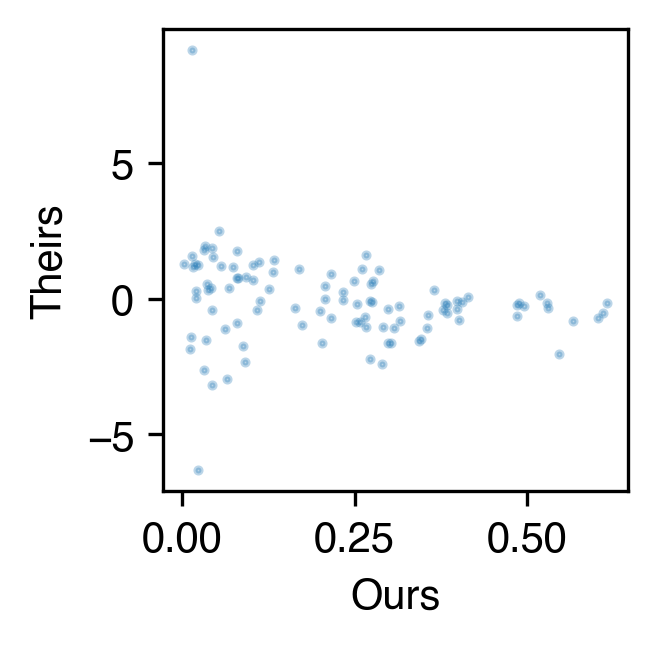

In [37]:
core_positions = [3.000, 5.000, 17.000, 19.000, 23.000, 25.000, 27.000, 36.000,
       38.000, 40.000, 45.000, 47.000, 52.000]

their_weights = binding_data.drop(columns=[-1])[core_positions].values.flatten()

core_positions = [int(n) - 1 for n in core_positions]
our_weights = conv_weights.loc[core_positions].T.values.flatten()

df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()
df = df[df['ours'] > 0]

print(pearsonr(df['theirs'], df['ours']))

plt.figure(figsize=(2, 2))
plt.scatter(df['ours'], df['theirs'], s=2, alpha=0.3)
plt.ylabel("Theirs")
plt.xlabel("Ours")
# plt.ylim(-5, 5)
# plt.yscale('log')

PearsonRResult(statistic=-0.19012800492819953, pvalue=0.007449645991957268)


Text(0.5, 0, 'Ours')

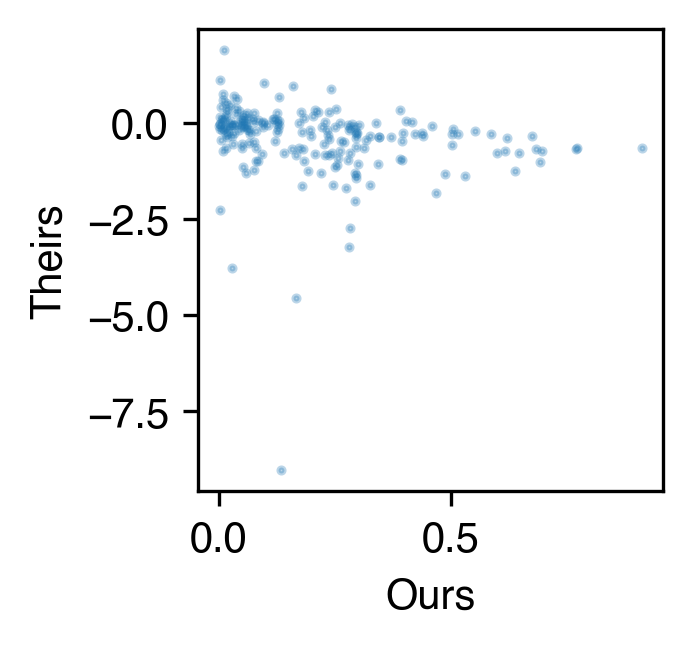

In [38]:
surface_positions = [1.000, 2.000, 4.000, 8.000, 10.000, 11.000, 14.000, 15.000, 18.000,
       20.000, 21.000, 22.000, 24.000, 26.000, 28.000, 29.000, 30.000,
       31.000, 33.000, 39.000, 41.000, 42.000, 43.000, 44.000, 49.000,
       53.000, 54.000, 55.000, 56.000]

their_weights = binding_data.drop(columns=[-1])[surface_positions].values.flatten()

surface_positions = [int(n) - 1 for n in surface_positions]
our_weights = conv_weights.loc[surface_positions].T.values.flatten()

df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()
df = df[df['ours'] > 0]

print(pearsonr(df['theirs'], df['ours']))

plt.figure(figsize=(2, 2))
plt.scatter(df['ours'], df['theirs'], s=2, alpha=0.3)
plt.ylabel("Theirs")
plt.xlabel("Ours")
# plt.ylim(-5, 5)
# plt.yscale('log')

PearsonRResult(statistic=-0.19012800492819953, pvalue=0.007449645991957268)


Text(0.5, 0, 'Ours')

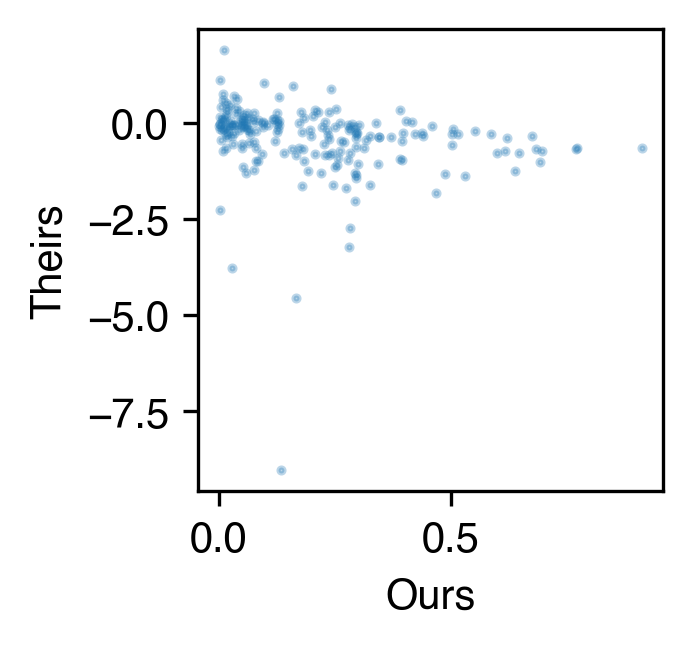

In [39]:
surface_positions = [1.000, 2.000, 4.000, 8.000, 10.000, 11.000, 14.000, 15.000, 18.000,
       20.000, 21.000, 22.000, 24.000, 26.000, 28.000, 29.000, 30.000,
       31.000, 33.000, 39.000, 41.000, 42.000, 43.000, 44.000, 49.000,
       53.000, 54.000, 55.000, 56.000]

their_weights = binding_data.drop(columns=[-1])[surface_positions].values.flatten()

surface_positions = [int(n) - 1 for n in surface_positions]
our_weights = conv_weights.loc[surface_positions].T.values.flatten()

df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()
df = df[df['ours'] > 0]

print(pearsonr(df['theirs'], df['ours']))

plt.figure(figsize=(2, 2))
plt.scatter(df['ours'], df['theirs'], s=2, alpha=0.3)
plt.ylabel("Theirs")
plt.xlabel("Ours")
# plt.ylim(-5, 5)
# plt.yscale('log')

PearsonRResult(statistic=-0.4498984516573368, pvalue=6.011624351275197e-39)
SignificanceResult(statistic=-0.5711248224462637, pvalue=1.1624765828722277e-66)


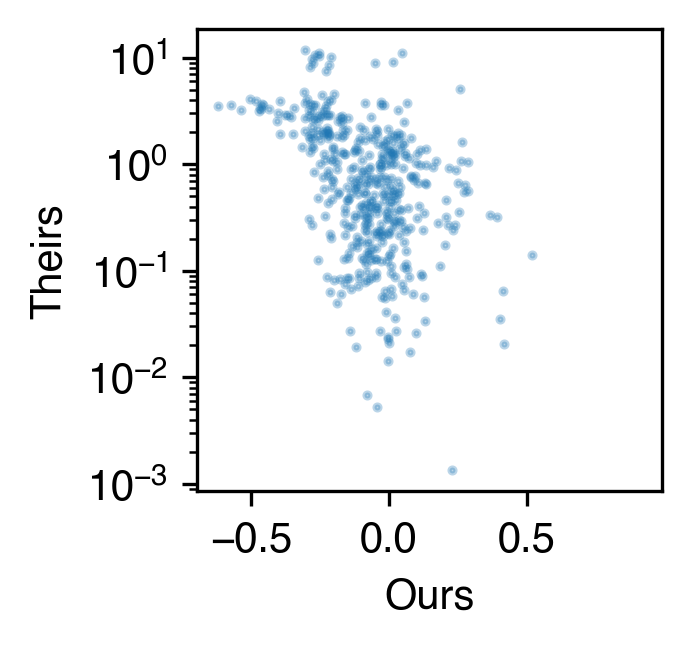

In [40]:
our_weights = conv_weights.T.values.flatten()
their_weights = binding_data.drop(columns=[-1]).values.flatten()

df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()
# df = df[df['ours'] > 0]

print(pearsonr(df['theirs'], df['ours']))
print(spearmanr(df['theirs'], df['ours']))

plt.figure(figsize=(2, 2))
plt.scatter(df['ours'], df['theirs'], s=2, alpha=0.3)
plt.ylabel("Theirs")
plt.xlabel("Ours")
# plt.ylim(-5, 5)
plt.yscale('log')

In [166]:
import tensorflow as tf

model_dir = "/Users/claireleblanc/Downloads/Data/mochi/GRB2-SH3/mochi__fit_tmodel_3state_sparse_dimsum128/whole_model/my_model_0/"
loaded = tf.saved_model.load(model_dir)

In [167]:
keras_model = tf.keras.models.load_model(model_dir)
keras_model.summary()

Model: "functional_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_fold (InputLayer)        [(None, 1057)]       0           []                               
                                                                                                  
 input_bind (InputLayer)        [(None, 757)]        0           []                               
                                                                                                  
 folding_additivetrait (Dense)  (None, 1)            1057        ['input_fold[0][0]']             
                                                                                                  
 binding_additivetrait (Dense)  (None, 1)            757         ['input_bind[0][0]']             
                                                                                       

In [168]:
additive_weights = keras_model.get_layer('folding_additivetrait').get_weights()
binding_additive_weights = keras_model.get_layer('binding_additivetrait').get_weights()

In [169]:
keras_model.get_layer('state_prob_bound').get_weights()

[]

In [170]:
params['NN_weights_folding'] = additive_weights[0]
params['NN_weights_binding'] = binding_additive_weights[0]
params

ValueError: Length of values (757) does not match length of index (1057)

# Seed correlations

In [45]:
def get_mean_weights(model_list, layer_num=1): 
    """
    Takes a list of models and averages their weights (should all have the same filter size).
    Averages models with positive and negative linear weights separately.

    Parameters 
    ----------
    model_list : list
        list of NNs 

    layer_num : int
        Which layer of the NN we are interested in

    Returns 
    -------
    mean_conv_array : np.array
        Mean of the convolutional weights for the given models
        which had positive linear weights
    mean_linear_array : np.array
        Mean of the linear weights for the given models
        which had poitive linear weights
    mean_conv_array_neg : np.array
        Mean of the convolutional weights for the given models
        which had negative linear weights
    mean_linear_array_neg : np.array
        Mean of the linear weights for the given models
        which had negative linear weights
    """
    conv_weights = []
    linear_weight_ls = []
    conv_array_neg = []
    linear_array_neg = []
    
    # Get the weights for each model
    for model in model_list:
        linear_weights = get_linear_weights(model, f"linear{layer_num}.weight")
        # Separate weights by positive and negative 
        if (linear_weights.sum() < 0):
            conv_array_neg.append(get_conv_weights(model, f"conv{layer_num}.weight").values)
            linear_array_neg.append(linear_weights)
        else: 
            conv_weight = get_conv_weights(model, f"conv{layer_num}.weight").values
            linear_weight_ls.append(linear_weights)
            conv_weights.append(conv_weight)

    # Average convolutional weights
    stacked_arrays = np.stack(conv_weights, axis=0)
    mean_conv_array = np.mean(stacked_arrays, axis=0)

    # Average positive linear weights
    stacked_arrays = np.stack(linear_weight_ls, axis=0)
    mean_linear_array = np.mean(linear_weight_ls, axis=0)

    # Average negative linear weights (if they exist)
    if len(conv_array_neg) > 0:
        stacked_arrays = np.stack(conv_array_neg, axis=0)
        mean_conv_array_neg = np.mean(stacked_arrays, axis=0)
        stacked_arrays = np.stack(linear_array_neg, axis=0)
        mean_linear_array_neg = np.mean(linear_array_neg, axis=0)
    else: 
        mean_conv_array_neg = np.array([])
        mean_linear_array_neg = np.array([])

    return mean_conv_array, mean_linear_array.flatten(), mean_conv_array_neg, mean_linear_array_neg.flatten()

def make_row_plot(fig, kernel_size, model_conv1, model_linear1, row, lim, height_ratios, num_rows, height_max=0, height_min=0):
    """
    Core functionality for creating the convolutional filter plots. 
    Plots the convolution filter as a heatmap and the linear weights as a bar plot.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object created with plt.figure
    
    kernel_size : int
        The size of the convolutional filter

    model_conv1 : np.array
        Averaged convolutional filter weights

    model_linear1 : np.array
        Averaged linear filter weights
    
    row : int
        Which row in the overall figure should we fill in

    lim : float
        The max value for the heatmap

    height_ratios : list
        Ratio of heights between rows, length should correspond to number of rows in
        gridspec object

    num_rows : list
        The number of rows in the gridspec object
    
    height_max : float
        The maximum value for the barplot

    height_min : float
        The minimum value for the barplot

    Returns
    -------
    ax1 : maplotlib.Axes object
        Contains the heatmap
    ax2 : maplotlib.Axes object
        Contains the barplot
    im1 : maplotlib.Axes.imshow object
        The heatmap
    """

    # Calculate how much of the figure the convolutional filter vs. linear weights will take up
    ratio1 = kernel_size 
    ratio2 = 40 - kernel_size + 1
    
    # GridSpec allows us to plot rows/columns with different dimensions
    # Here, we initalize the gridspec object with the total number of rows in our figure
    # But we only fill in the specific row that we are interested in
    # (When combined with many other gridspec objects, they will all line up and look good)
    gs1 = gridspec.GridSpec(2 + num_rows*2, 2, width_ratios=[ratio1, ratio2], height_ratios=height_ratios, figure=fig)
    
    # ax1 and ax2 are matplotlib axes
    ax1 = plt.subplot(gs1[row, 0])
    ax2 = plt.subplot(gs1[row, 1])

    # This is the code for plotting the convolutional filter as a heatmap
    # Min and max values of heatmap are passed by used
    im1 = ax1.imshow(model_conv1, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    ax1.set_yticks(range(len(amino_acids)), amino_acids)  # Label x-axis with column names
    ax1.set_xticks(np.arange(kernel_size, step=2))
    
    # This is to color the amino acid labels
    for ytic in ax1.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax1.tick_params(axis='x', which='major', labelsize=15) 
    ax1.tick_params(axis='y', which='major', labelsize=8) 

    # This is the code for plotting the linear weights as a bar graph
    ax2.bar(range(len(model_linear1)), model_linear1, color="grey")
    ax2.set_ylim(height_min, height_max)
    
    ax2.spines["top"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["bottom"].set_position('zero')
    ax2.spines["bottom"].set_linewidth(2.5)
    ax2.spines['bottom'].set_bounds(-1, len(model_linear1))
    
    # Remove all x-ticks for the bargraph
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_xticklabels([])
    ax2.set_yticklabels([])

    return ax1, ax2, im1

def get_linear_weights(model, layer):
    """
    Extracts the linear weights to the NN
    and returns a numpy array
    """
    model_state_dict = model.state_dict()
    linear_weights = model_state_dict[layer].detach().numpy()
    return linear_weights


def make_multi_filter_plot_mean(models, kernel_sizes, positive=True, layer_num=1):
    """
    Generates the final figure by calling make_row_plot for each filter size
    Plots the mean params for each filter size

    Parameters
    ----------
    models : list
        List of lists of NNs (one list per each conv. filter size)
    
    kernel_sizes : list
        List of kernel sizes, should correspond to models list
    
    positive : bool
        Whether to plot positive linear weights. If False, will plot 
        negative linear weights
    
    layer_num : int
        Which layer of the NN are we interested in 
    """
    
    conv_weights = []
    linear_weights = []
    updated_kernel_sizes = []

    # Get average parameters for each model
    for k, model in zip(kernel_sizes, models): 
        if positive: 
            conv1_weights, linear1_weights, _ , _ = get_mean_weights(model, layer_num)
            conv_weights.append(conv1_weights)
            linear_weights.append(linear1_weights)
            updated_kernel_sizes.append(k)
        else: 
            _, _, conv1_weights, linear1_weights = get_mean_weights(model, layer_num)
            if len(linear1_weights) > 0: 
                conv_weights.append(conv1_weights)
                linear_weights.append(linear1_weights)
                updated_kernel_sizes.append(k)

    num_rows = len(linear_weights) 

    if num_rows == 0:
        print("No models matching parameters")
        return

    # Get heatmap range
    lim = max([abs(w) for w in np.concatenate([ls.flatten() for ls in conv_weights])])

    # Get barplot range
    height_max = max(0, max([max(ls) for ls in linear_weights]))
    height_min = min(0, min([min(ls) for ls in linear_weights]))

    # Create a figure
    fig = plt.figure(figsize=(10, 3*num_rows))

    # Add padding between rows
    height_ratios = [.01] + [3.3, .1]*num_rows + [0.1]

    # Add row plots
    ax1, ax2, im1 = make_row_plot(fig, updated_kernel_sizes[0], conv_weights[0].T, linear_weights[0], 1, lim, height_ratios, num_rows, height_max, height_min)

    ax1.set_title("Convolutional Filter", fontsize=12)
    ax2.set_title("Linear weights", fontsize=12)
    
    for i, (conv_weight, linear_weight, k) in enumerate(zip(conv_weights[1:], linear_weights[1:], updated_kernel_sizes[1:])):
        make_row_plot(fig, k, conv_weight.T, linear_weight, 3+i*2, lim, height_ratios, num_rows, height_max, height_min)

    # Add colorbar
    gs_cb = gridspec.GridSpec(2 + num_rows*2, 1, width_ratios=[1], height_ratios=height_ratios, figure=fig)
    cax1 = plt.subplot(gs_cb[-1,0])

    fig.colorbar(im1,cax=cax1, orientation='horizontal')

In [50]:
size = (1,56,20)
import torch 

def load_model(name, k, ak):
    """
    Loads ADModel_two_state_abund
    """
    model = ADModel_two_state_abund(size, "Hill", k, relu=False, abund_k=ak)
    model.load_state_dict(torch.load(f"{name}.pth"))
    return model

models = []

# Load each NN and save in a list
for index in two_model_results[two_model_results['pearson_act_val'] > 0.7].index:
    K = two_model_results.loc[index, "kernel_size"]
    name = two_model_results.loc[index, "model_name"].removeprefix("../../")
    ak = 56

    models.append(load_model(name, K, ak))


In [71]:
pearson_r = np.array(pearson_r)

pearson_r[pearson_r < 0.9999].max()

0.97160864

In [63]:
pearson_r = []
spearman_r = []
for model1 in models:
    for model2 in models: 
        our_weights = get_conv_weights(model1, "conv1.weight").T.values.flatten()
        # our_weights = conv_weights[0].T.flatten()
        # their_weights = binding_data.drop(columns=[-1]).values.flatten()
        their_weights = get_conv_weights(model2, "conv1.weight").T.values.flatten()


        df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()

        print(pearsonr(df['theirs'], df['ours']).correlation, spearmanr(df['theirs'], df['ours']).correlation)
        pearson_r.append(pearsonr(df['theirs'], df['ours']).correlation)
        spearman_r.append(spearmanr(df['theirs'], df['ours']).correlation)

1.0 0.9999999999999998
0.9101809 0.7631396845364649
0.21708903 0.1259440605193631
0.22406803 0.13265515141969522
0.22441246 0.13895756340002546
0.21748634 0.12372650738948064
0.910181 0.7631396845364649
1.0 0.9999999999999998
0.3197686 0.21198512195880254
0.312499 0.21631180407054346
0.32923073 0.23132539680641595
0.31924742 0.22610087152720712
0.21708906 0.1259440605193631
0.31976858 0.21198512195880254
0.9999999 0.9999999999999998
0.96071446 0.8764463443108155
0.97160864 0.8809341593635106
0.9708894 0.8866349257977041
0.22406803 0.13265515141969522
0.312499 0.21631180407054346
0.96071446 0.8764463443108155
1.0 0.9999999999999998
0.9481691 0.8783570999794664
0.9600427 0.8819259746813299
0.22441246 0.13895756340002546
0.32923073 0.23132539680641595
0.97160864 0.8809341593635106
0.9481691 0.8783570999794664
0.99999994 0.9999999999999998
0.96760345 0.8793114272253086
0.21748632 0.12372650738948064
0.3192474 0.22610087152720712
0.9708894 0.8866349257977041
0.9600427 0.8819259746813299
0.9

In [57]:
pearson_r = []
spearman_r = []
for model1 in models:
    our_weights = get_conv_weights(model1, "conv1.weight").T.values.flatten()
    # our_weights = conv_weights[0].T.flatten()
    their_weights = binding_data.drop(columns=[-1]).values.flatten()
    # their_weights = get_conv_weights(model2, "conv1.weight").T.values.flatten()


    df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()

    print(pearsonr(df['theirs'], df['ours']).correlation, spearmanr(df['theirs'], df['ours']).correlation)
    pearson_r.append(pearsonr(df['theirs'], df['ours']).correlation)
    spearman_r.append(spearmanr(df['theirs'], df['ours']).correlation)

-0.4498984516573368 -0.5711248224462637
-0.47078237142876117 -0.628008283457206
-0.46617394459047967 -0.49541861717144076
-0.44831461437061093 -0.4858048244070097
-0.4663941876716141 -0.5050440744300263
-0.4636196457211391 -0.49136576090480927


In [59]:
mean_weights = get_mean_weights(models)


PearsonRResult(statistic=-0.561391010364853, pvalue=5.3670429881745414e-64)
SignificanceResult(statistic=-0.6458957852433317, pvalue=1.81239074658217e-90)


(-5.0, 5.0)

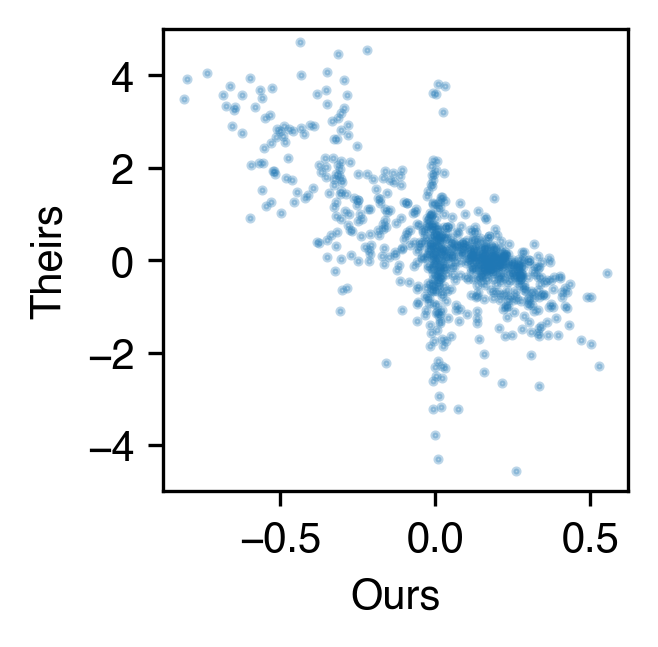

In [60]:
our_weights = mean_weights[0].T.flatten()
their_weights = binding_data.drop(columns=[-1]).values.flatten()

df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()

print(pearsonr(df['theirs'], df['ours']))
print(spearmanr(df['theirs'], df['ours']))

plt.figure(figsize=(2, 2))
plt.scatter(df['ours'], df['theirs'], s=2, alpha=0.3)
plt.ylabel("Theirs")
plt.xlabel("Ours")
plt.ylim(-5, 5)


[[0.001]]
[[1.054]]
[[0.001]]
[[0.530]]
[[0.006]]
[[0.775]]
[[0.495]]
[[0.753]]
[[0.888]]
[[0.002]]


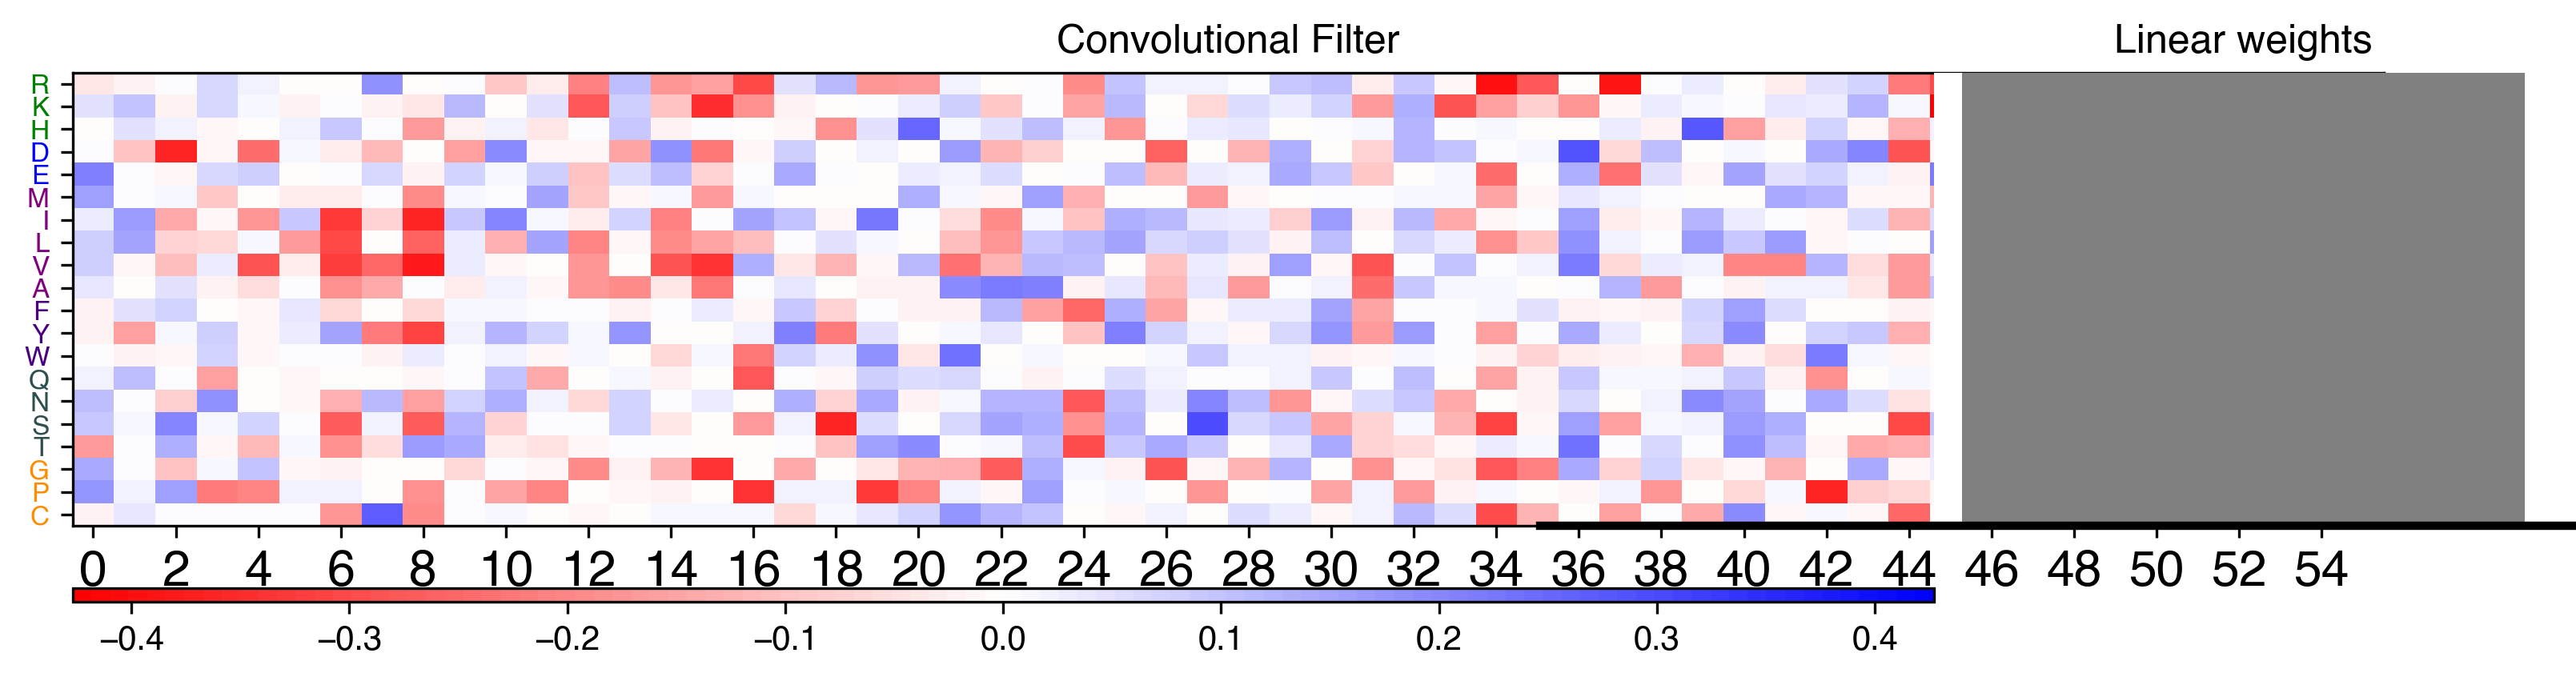

In [146]:
make_multi_filter_plot_mean([models], [56])

# Making convolutional filter plots -> Three state

In [ ]:
# Same colors as before, not sure why I'm redefinint them here

colors = [(1, 0, 0), (1, 1, 1), (0, 0, 1)]  # Red, White, Blue
n_bins = 100  # Number of color bins
cmap_name = "custom_colormap"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
custom_cmap.set_bad(color='white', alpha=1.0)  # Handle NaN values, if any
colors = {'A': 'purple', 'C': 'darkorange', 'E': 'blue', 'D': 'blue', 'G': 'darkorange', 
                  'F': 'indigo', 'I': 'purple', 'H': 'green', 'K': 'green', 'M': 'purple', 
                  'L': 'purple', 'N': 'darkslategray', 'Q': 'darkslategray', 'P': 'darkorange', 'S': 'darkslategray', 
                  'R': 'green', 'T': 'darkslategray', 'W': 'indigo', 'V': 'purple', 'Y': 'indigo'}

In [ ]:
def make_row_plot_abund(fig, kernel_size, model, row, lim, height_ratios, num_rows, abund_kernel_size):
    """
    Core functionality for creating the convolutional filter plots. 
    Plots the convolution filter as a heatmap and the linear weights as a bar plot.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object created with plt.figure
    
    kernel_size : int
        The size of the convolutional filter

    model : ADModel_abund
        Loaded model (from which parameters will be extracted)
    
    row : int
        Which row in the overall figure should we fill in

    lim : float
        The max value for the heatmap

    height_ratios : list
        Ratio of heights between rows, length should correspond to number of rows in
        gridspec object

    num_rows : list
        The number of rows in the gridspec object
    
    abund_kernel_size : int
        The size of the abundance kernel (can be different from other kernel sizes)

    Returns
    -------
    ax1-6 : maplotlib.Axes object
        Contains the heatmaps and barplots
    im1-3 : maplotlib.Axes.imshow object
        The heatmaps
    """

    # Load the parameters for the K1 module
    model_conv1 = get_conv_weights(model, "conv1.weight").T
    model_linear1, model_xvals1 = get_linear_weights(model, "linear1.weight", kernel_size)

    # Load the parameters for the K2 module
    model_conv2 = get_conv_weights(model, "conv2.weight").T
    model_linear2, model_xvals2 = get_linear_weights(model, "linear2.weight", kernel_size)

    # Load the parameters for the abundance module
    model_conv3 = get_conv_weights(model, "conv3.weight").T
    model_linear3, model_xvals3 = get_linear_weights(model, "linear3.weight", abund_kernel_size)

    # Calculate how much of the figure the convolutional filter vs. linear weights will take up
    ratio1 = kernel_size 
    ratio2 = 40 - kernel_size + 1
    ratio1_abund = abund_kernel_size
    ratio2_abund = 40 - abund_kernel_size + 1

    # GridSpec allows us to plot rows/columns with different dimensions
    # Here, we initalize the gridspec object with the total number of rows in our figure
    # But we only fill in the specific row that we are interested in
    # (When combined with many other gridspec objects, they will all line up and look good)
    gs1 = gridspec.GridSpec(2 + num_rows, 8, width_ratios=[ratio1, ratio2, 0.5, ratio1, ratio2, 0.5, ratio1_abund, ratio2_abund], height_ratios=height_ratios, figure=fig)
    
    # Maplotlib axes
    ax1 = plt.subplot(gs1[row, 0])
    ax2 = plt.subplot(gs1[row, 1])
    ax3 = plt.subplot(gs1[row, 3])
    ax4 = plt.subplot(gs1[row, 4])
    ax5 = plt.subplot(gs1[row, 6])
    ax6 = plt.subplot(gs1[row, 7])

    # Plotting K1 heatmap
    im1 = ax1.imshow(model_conv1.to_numpy(), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    ax1.set_yticks(range(len(model_conv1.index)), model_conv1.index)  # Label x-axis with column names
    ax1.set_xticks(np.arange(kernel_size, step=2))

    # This is to color the amino acid labels
    for ytic in ax1.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax1.tick_params(axis='both', which='major', labelsize=6) 

    # Plotting K1 barplot
    ax2.bar(model_xvals1, model_linear1, color="grey")
    ax2.spines["top"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["bottom"].set_position('zero')
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_xticklabels([])
    ax2.set_yticklabels([])

    # Plotting K2 heatmap
    im2 = ax3.imshow(model_conv2.to_numpy(), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    ax3.set_yticks(range(len(model_conv2.index)), model_conv2.index)  # Label x-axis with column names
    ax3.set_xticks(np.arange(kernel_size, step=2))
    
    # Color the aa labels
    for ytic in ax3.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax3.tick_params(axis='both', which='major', labelsize=6) 

    # Plotting K2 bargraph
    ax4.bar(model_xvals2, model_linear2, color="grey")
    ax4.spines["top"].set_visible(False)
    ax4.spines["left"].set_visible(False)
    ax4.spines["right"].set_visible(False)
    ax4.spines["bottom"].set_position('zero')
    ax4.set_xticks([])
    ax4.set_yticks([])
    ax4.set_xticklabels([])
    ax4.set_yticklabels([])

    # Plotting abundance heatmap
    im3 = ax5.imshow(model_conv3.to_numpy(), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    ax5.set_yticks(range(len(model_conv3.index)), model_conv3.index)  # Label x-axis with column names
    ax5.set_xticks(np.arange(abund_kernel_size, step=2))

    # Changing aa label color
    for ytic in ax5.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax5.tick_params(axis='both', which='major', labelsize=6) 

    # Plotting abundance bar graph
    ax6.bar(model_xvals3, model_linear3, color="grey")
    ax6.spines["top"].set_visible(False)
    ax6.spines["left"].set_visible(False)
    ax6.spines["right"].set_visible(False)
    ax6.spines["bottom"].set_position('zero')
    ax6.set_xticks([])
    ax6.set_yticks([])
    ax6.set_xticklabels([])
    ax6.set_yticklabels([])

    return ax1, ax2, ax3, ax4, ax5, ax6, im1, im2, im3

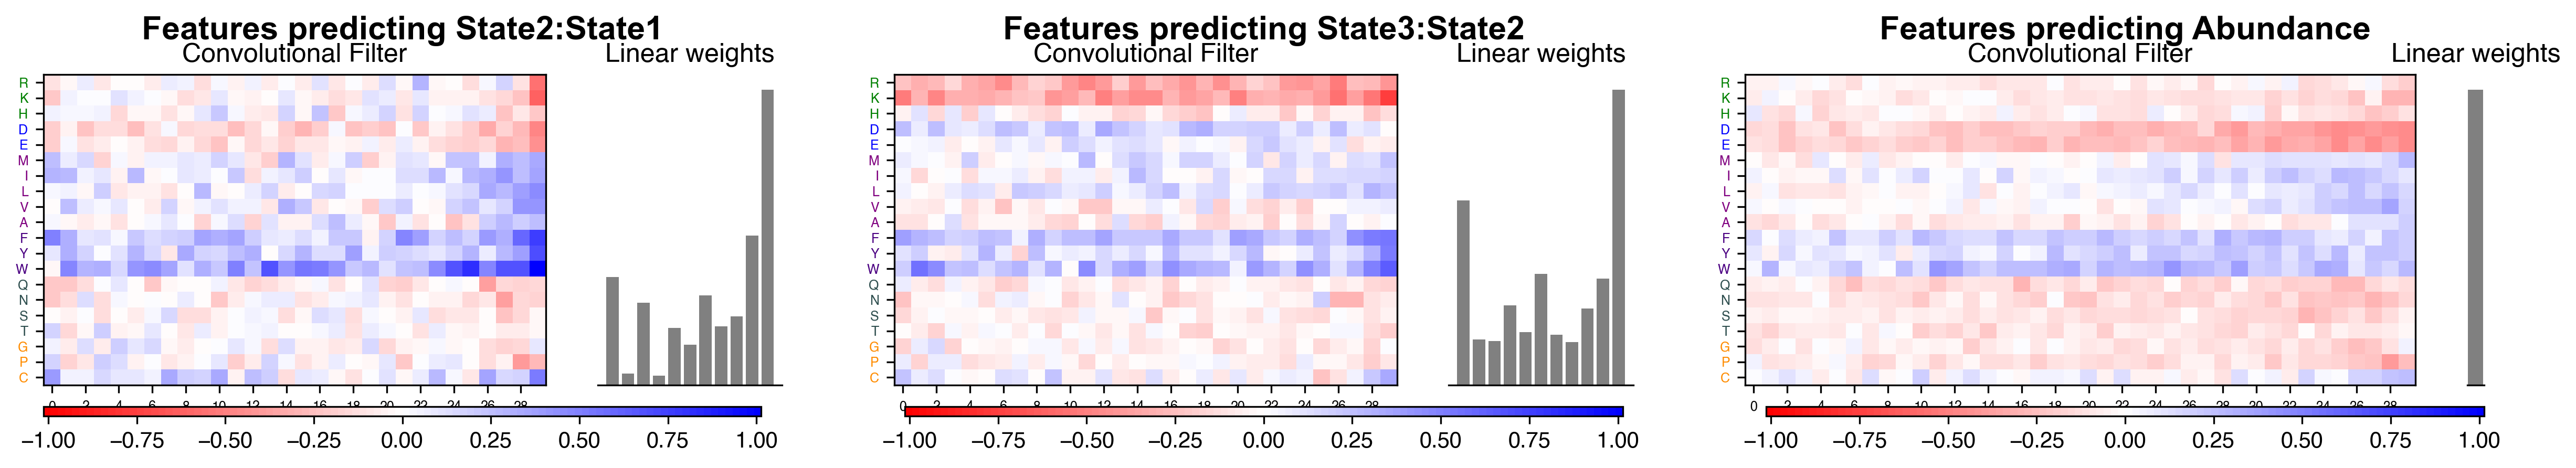

In [ ]:
num_rows = 1

# Get the max value for the heatmaps
models = [three_state_biophysical_model]
conv_weights = []

for model in models: 
    conv_weights += list(get_conv_weights(model, "conv1.weight").T.values.flatten())
    conv_weights += list(get_conv_weights(model, "conv2.weight").T.values.flatten())

lim = max([abs(w) for w in conv_weights])

# Create a figure
fig = plt.figure(figsize=(20, 3*num_rows))
title_font = {'fontsize': 15, 'fontweight': 'bold', 'fontname': 'Arial'}

# We add in "padding" rows between the rows we care about
height_ratios = [.01] + [3.3]*num_rows + [.1]

# Create a gridspec object for the title 
gs1 = gridspec.GridSpec(2 + num_rows, 3, width_ratios=[1,1,1], height_ratios=height_ratios, figure=fig)

# Title for the K1 parameters
ax1 = plt.subplot(gs1[0,0])
ax1.set_title("Features predicting State2:State1", fontdict=title_font)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.patch.set_visible(False)
ax1.axis('off')

# Title for the K2 parameters
ax2 = plt.subplot(gs1[0,1])
ax2.set_title("Features predicting State3:State2", fontdict=title_font)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.patch.set_visible(False)
ax2.axis('off')

# Title for the abundance parameters
ax3 = plt.subplot(gs1[0,2])
ax3.set_title("Features predicting Abundance", fontdict=title_font)
ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_xticklabels([])
ax3.set_yticklabels([])
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.patch.set_visible(False)
ax3.axis('off')

# Plot the parameters in a single row
ax1, ax2, ax3, ax4, ax5, ax6, im1, im2, im3 = make_row_plot_abund(fig, kernel_size_three, three_state_biophysical_model, 1, lim, height_ratios, num_rows, abund_k_three)

# Add titles
ax1.set_title("Convolutional Filter", fontsize=12)
ax2.set_title("Linear weights", fontsize=12)
ax3.set_title("Convolutional Filter", fontsize=12)
ax4.set_title("Linear weights", fontsize=12)
ax5.set_title("Convolutional Filter", fontsize=12)
ax6.set_title("Linear weights", fontsize=12)

# Create gridspec object for the colorbar
gs_cb = gridspec.GridSpec(2 + num_rows, 3, width_ratios=[1,1,1], height_ratios=height_ratios, figure=fig)
cax1 = plt.subplot(gs_cb[1 + num_rows,0])
cax2 = plt.subplot(gs_cb[1 + num_rows,1])
cax3 = plt.subplot(gs_cb[1 + num_rows,2])

# Add the colorbar
fig.colorbar(im1,cax=cax1, orientation='horizontal')
fig.colorbar(im2, cax=cax2, orientation='horizontal')
fig.colorbar(im3, cax=cax3, orientation='horizontal')

# plt.savefig('figures/PADI_three_state_parameters.pdf', dpi=1000, bbox_inches='tight')